# Project 2: Reinforcement Learning

### Group #1
### Anton Mlynczyk - 1007283226
### Osman Sultan - 1006803014
### Sunghoo (Kevin) Kim - 1006820013
### Gaeun (Grace) Yim - 1011904824

Please read all instructions carefully before attempting each part of the problem. Each team only needs to have one submission with all the names of team-members and group number at the beginning of the jupyter notebook.

The jupyter notebook should contain your code, discussions, derivations, analysis and relevant figures. Make sure the code and plots shown in your file can be reproduce when I rerun the code in grading. Feel free to add or move Cells.

In Project 1, you were asked to implement two exact algorithms to solve the Frozen Lake. In this project, you will be asked to implement four different model-free algorithms to solve a similar problem with larger state space, and compare your results.

## 1. The Flags Domain

In the Flags domain, time is broken up into discrete decision periods, and the world is a
square area that is broken up into a 5-by-5 grid of cells, as illustrated in Figure 1 below.
At the beginning of each period, a robot occupies one of the available cells. It is then
allowed to choose a direction of movement (up, down, left or right), and moves to the
corresponding adjacent cell in that direction. However, if the chosen action would take
the robot outside the boundaries of the grid, the robot does not move but remains in
the current cell.

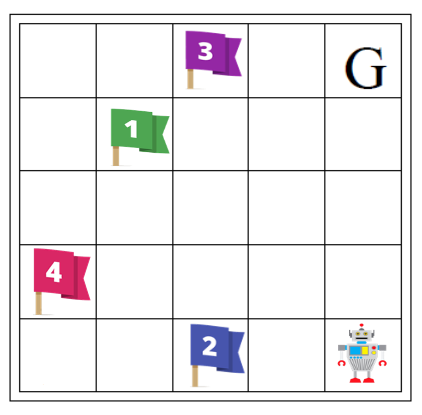



<h1><center>Figure 1: 5x5 Flags Domain</center></h1>

In each episode, the robot begins in the right lower corner. As illustrated in Figure 1, instead of a single
destination G, there are four different flags, numbered 1, 2, 3 and 4, that must be
collected in the correct order (first 1, then 2, etc... to 4). Once the robot has collected all the flags in the correct order and lands on cell G, the task is complete. If the robot collects the wrong flag at the wrong time (e.g. tries to collect 2 first, then 1...), the robot does not have to start over. Instead, the robot is penalized for taking this action, and the wrong flag is not collected (you may assume for training purposes, that the flags that have already been collected so far are kept). The main objective is to collect all the flags in the correct order in the least possible amount of time.

### 2. Problem modelling [15 Marks]

You are tasked with modelling the Flags environment. Then, you are asked to provide a programming description of the problem that will be used to solve it computationally using model-free reinforcement learning.

2.1.Answer the following questions:

(a) Define the state $(S)$ and action spaces $(A)$.[2 Marks]

**State Space**: 

State Space = $\{s_{ijk}\}$, $\forall$ $i = 0, 1, 2, 3, 4$ (row number top to down), $\forall$ $j = 0, 1, 2, 3, 4$ (col number starting from left to right), $\forall$ $k = 0, 1, 2, 3, 4$ (flag number captured)

Each state is a tuple containing: (grid position (i), grid position (j), flag most recently acquired (k))

From above set, remove the following impossible states: (1, 1, 0), (4, 2, 1), (0, 2, 2), (3, 0, 3). These states are impossible becuase we assume that once the robot reaches a cell with the subsequent flag, it will capture it. Thus, it is not possible to have a state where the robot reaches a cell with the next flag, and the flag number (k) does not increase by 1.

Total number of states $= 5^3 - 4$ $= 121$

**Action Space**:

$\{l, r, u, d\}$

Corresponding to left, right, up, down respectively.

(b) Construct a reward function ($R$) that aligns with the goal(s) you want your robot to achieve. [2 Marks]

$R(s', a, s)=
\begin{cases}
    -20 - \text{ManhattanDistance between robot curr location and flag k+1 (or goal if k==4)}, & \text{if s' contains flag > k+1}, \\
    -\text{ManhattanDistance between robot curr location and flag k+1 (or goal if k==4)}, & \text{otherwise}
\end{cases}$

(c) Based on Figure 1, what is an optimal policy for this problem? You may explain your policy by drawing Figure 1 and trace the path the robot should take. Is there more than one optimal policy?[3 Marks]

There are in total 24,400 optimal policies. Each optimal policy is a combination of optimal policies from each subtask involving capturing the subsequent flag and reaching the goal in the end (S(init)->F1 (Flag 1), F1->F2, F2->F3, F3->F4, F4->G (Goal)). Also, each subtask has multiple optimal paths. For example, S->F1 has total 16 optimal paths, and F1->F2 has total 4 optimal paths. The total number of optimal policies for the overall problem should be a product of each subtask's total number of optimal policies (16 x 4 x 1 x 10 x 35 = 22,400). 

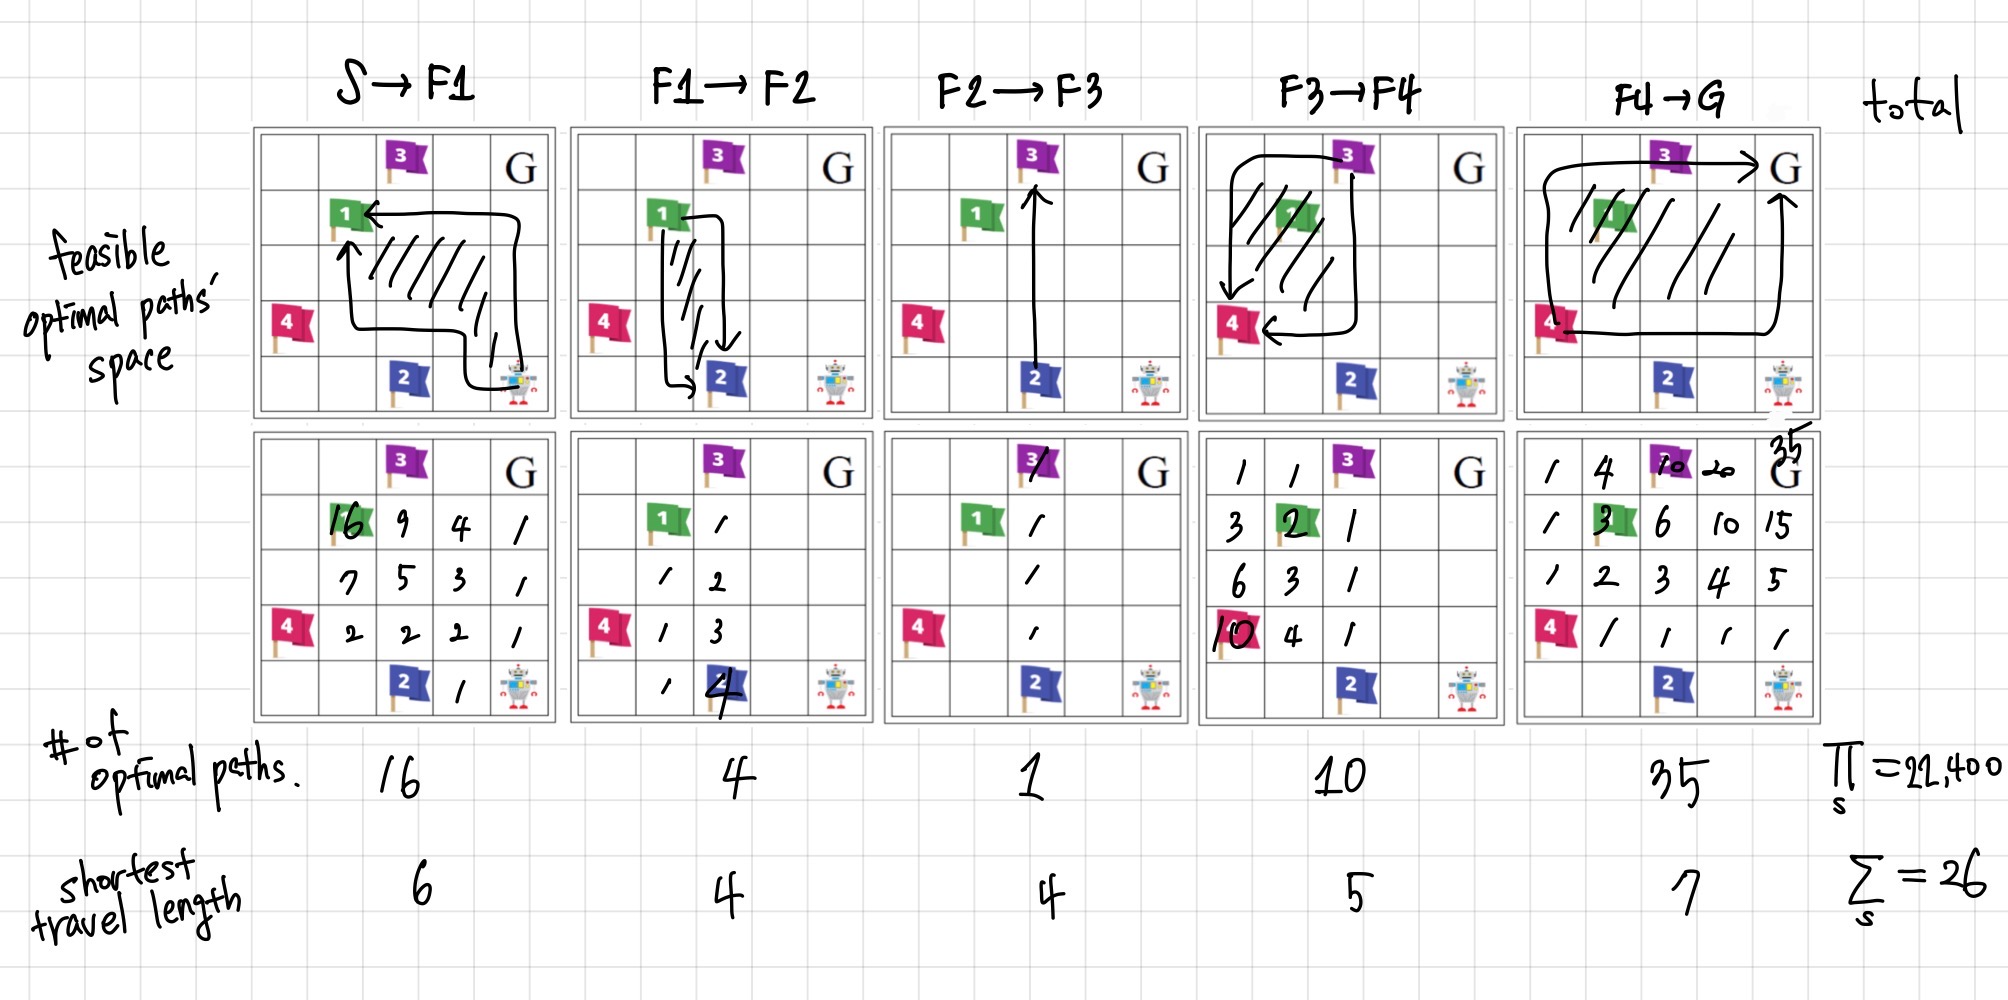


Below are three examples of optimal policies. All of them have a total travel length of 26.

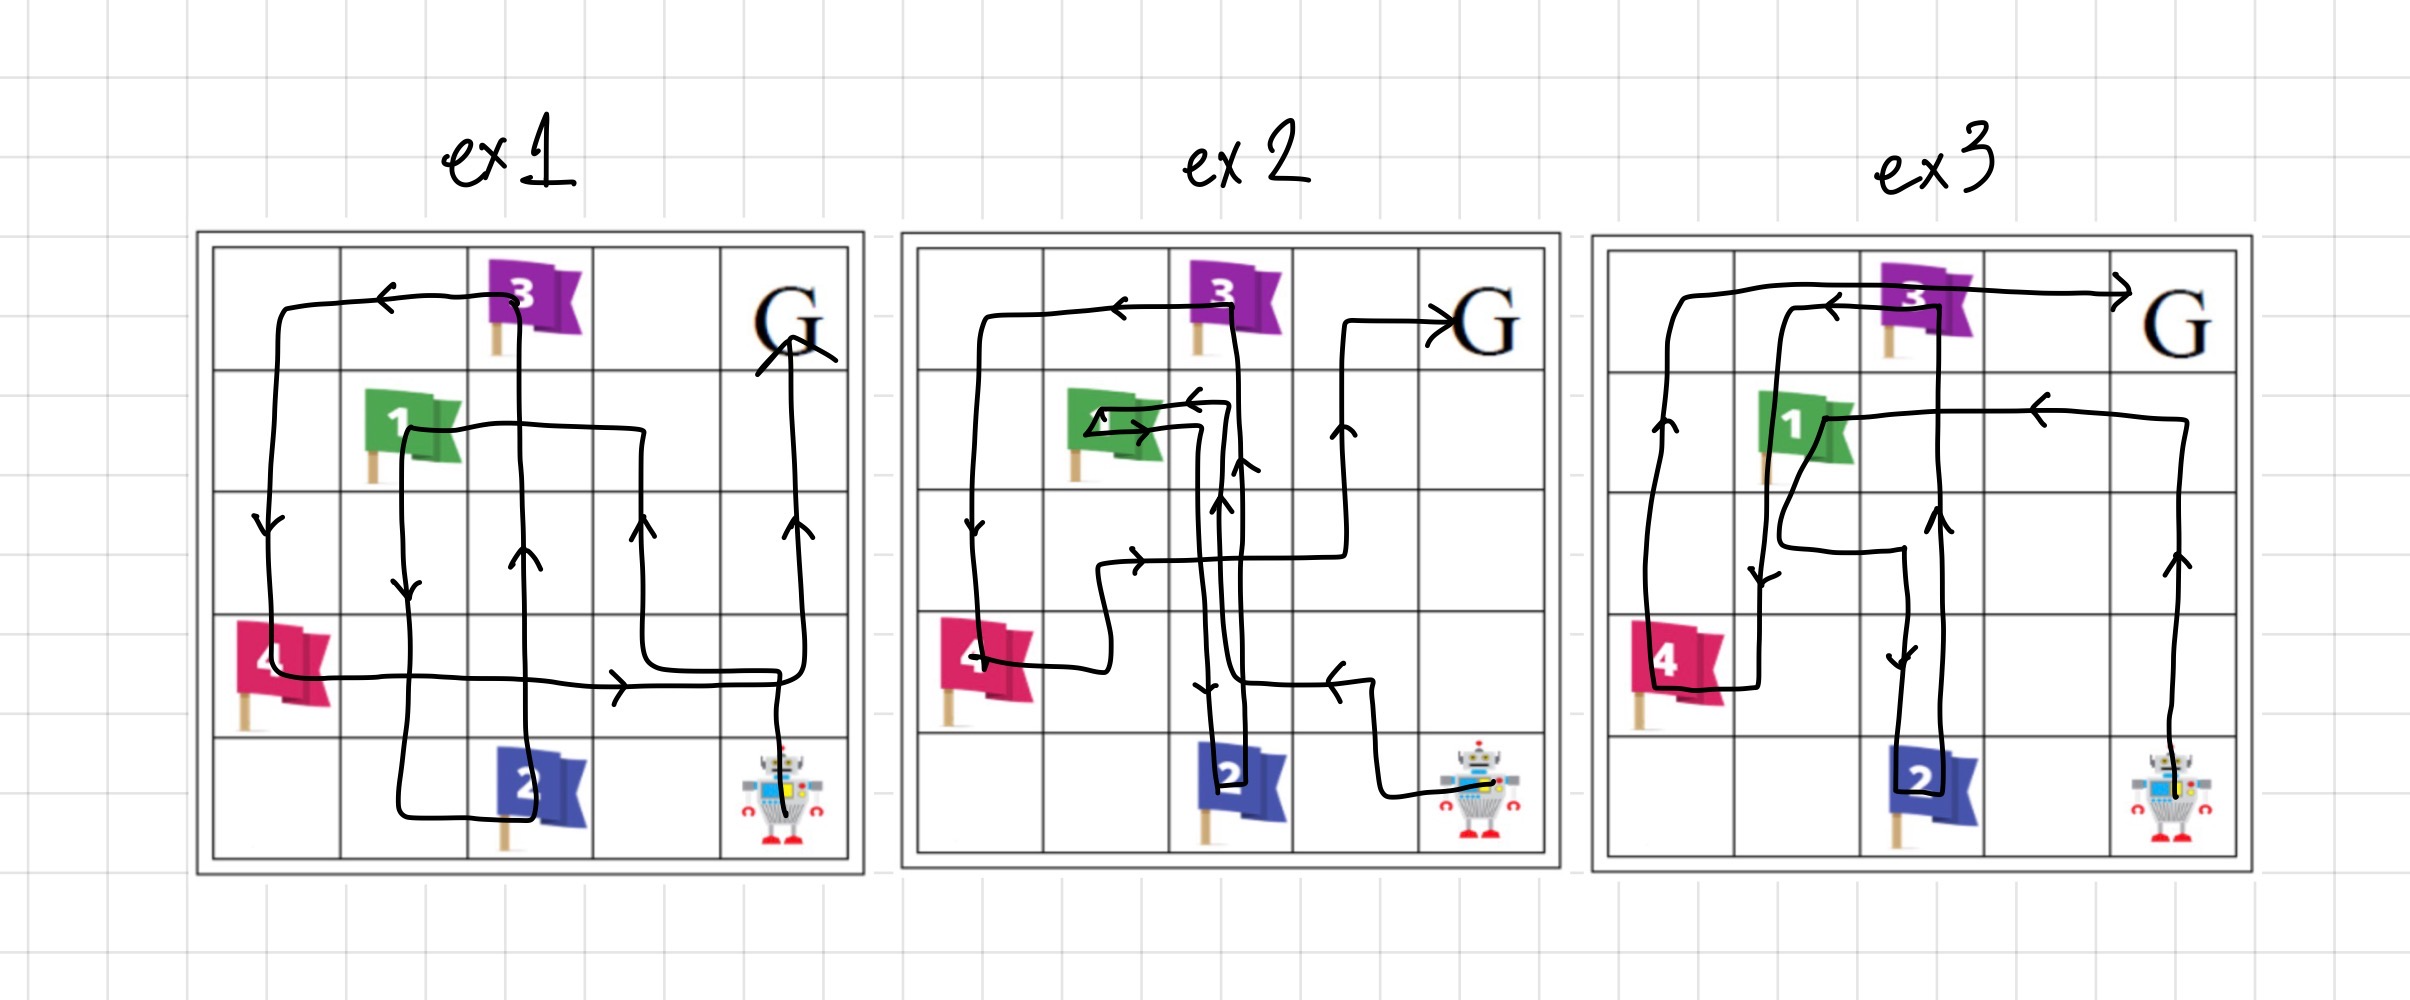

2.2 Implement the dynamics of the Flags environment. [8 Marks]

In [76]:
# imports
import random
from matplotlib import pyplot as plt

In [99]:
class Flags:
    def __init__(self):
        self.init_state = (4, 4, 0)     # state tuple (x, y, recent_flag_captured). recent_flag_captured = 0 if none captured
        self.goal_state = (0, 4, 4)     
        self.goal_loc = (0, 4)
        self.flag_locs = {1: (1, 1), 2: (4, 2), 3: (0, 2), 4: (3, 0)}
        self.loc_flags = {(1, 1): 1, (4, 2): 2, (0, 2): 3, (3, 0): 4}
        self.map_action_to_movement = {'l': (0, -1), 'r': (0, 1), 'u': (-1, 0), 'd': (1, 0)}

    # return the initial state ...
    def reset(self):
        return self.init_state

    # return a list containing all the possible states in the environment
    def states_space(self):
        # there are 4 invalid states which are not possible; (1, 1, 0), (4, 2, 1), (0, 2, 2), (3, 0, 3)
        all_states_space = [(x, y, flag) for x in range(5) for y in range(5) for flag in range(5)]
        invalid_states_space = []
        for flag, loc in self.flag_locs.items():
            invalid_states_space.append((loc[0], loc[1], flag-1))
        valid_states_space = list(set(all_states_space) - set(invalid_states_space))
        return valid_states_space
    
    # checks whether the provided grid location is within bounds
    def check_valid_loc(self, loc): 
        if not(0 <= loc[0] <= 4) or not(0 <= loc[1] <= 4):
            return False
        return True

    # return a list containing all the possible actions corresponding to the given state
    def actions_space(self, state):
        return ['l', 'r', 'u', 'd']

    # dense reward
    def reward(self, state, next_state):
        new_loc, curr_flag = next_state[:2], state[-1]
        
        # check whether the state is already goal state
        if next_state == self.goal_state:
            return 0

        penalty = 0

        # if goal cell reached too early, penalize
        if new_loc == self.goal_loc and curr_flag < 4:
            penalty = -20

        # if incorrect flag captured, penalize
        if new_loc in self.loc_flags:
            if (self.loc_flags[new_loc] > curr_flag + 1):  
                penalty = -20

        # Determine target: either the next flag or the goal if all flags are collected
        target = self.goal_loc if curr_flag == 4 else self.flag_locs[curr_flag + 1]

        # Return negative Manhattan distance + penalty
        return -1 * (abs(target[0] - new_loc[0]) + abs(target[1] - new_loc[1])) + penalty
    
    # environment transition returns s' and r.
    def transition(self, state, action):

        # if given state is already a goal state, terminate
        if state == self.goal_state:
            return self.goal_state, self.reward(state, self.goal_state)

        # get new location with given state and action
        movement = self.map_action_to_movement[action]
        new_loc, curr_flag = (state[0] + movement[0], state[1] + movement[1]), state[-1]

        if not self.check_valid_loc(new_loc): # if new_loc is out of bounds, don't move
            new_loc = state[:2]

        # get new_flag to create next_state
        if curr_flag == 4:
            new_flag = curr_flag
        else:
            if new_loc in self.loc_flags:
                flag_at_loc = self.loc_flags[new_loc]
                if flag_at_loc == curr_flag + 1: # if the new grid location has a flag and it is the next flag (correct), capture it
                    new_flag = curr_flag + 1
                else: # wrong flag or visiting an old flag
                    new_flag = curr_flag
            else: # moving to empty space without flag
                new_flag = curr_flag
        
        # get next_state
        next_state = (new_loc[0], new_loc[1], new_flag)
        
        return next_state, self.reward(state, next_state)

### 3 Monte Carlo Method [35 Marks]

In this section, you are asked to implement Monte Carlo methods to solve the flags domain. Use a discount factor of
$\gamma= 0.99$ for all your experiments.Set the maximum length of each episode to 200 if the terminal state is not reached by this point, the episode ends. Training should proceed for a total of 2000 episodes.


3.1. Create a function $generate\_episode$ which takes as input a policy $\pi$ and the environment. This function should return the tuple of states, actions and rewards generated in an episode following $\pi$.    [5 Marks]

In [108]:
# 3.1 - Generate Episode

def generate_episode(init_state: tuple, init_action: str, policy: dict, env: Flags):
    goal_state = env.goal_state
    curr_state, init_reward = env.transition(init_state, init_action)
    states, actions, rewards = [init_state], [init_action], [init_reward]
    t = 1   # since S_0, A_0, R_1 already initialized and appended to array

    while curr_state != goal_state and t < 200:
        action = random.choices(env.actions_space(curr_state), weights=policy[curr_state])[0]
        next_state, reward = env.transition(curr_state, action)
        states.append(curr_state)               # S_t
        actions.append(action)                  # A_t
        rewards.append(reward)                  # R_t+1
        curr_state = next_state
        t += 1
    
    return states, actions, rewards

3.2. Implement the first-visit Monte Carlo (for $\epsilon$-soft policies) control algorithm to find the approximate optimal
policy $\pi^*$. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and include plots in your report for each of these values. What is the best value of $\epsilon$? Why? For each $\epsilon$, did your algorithm converge at all? What was the final policy and
Q-values that you typically obtain (typically, as in the majority of the trials)? Does this correspond to an optimal policy? Visualize the learning process (for instance, change in Q for some state; or any other visualization) to support your claims.  [15 Marks]

In [109]:
# 3.2 - Plotting helper function

def create_plots(env, q, policy, epsilon=None, sampling_type=None, epoch=2000):

    # plot the q values for each state
    fig1, axis1 = plt.subplots(1, 5, figsize=(50, 10))
    if sampling_type:
        fig1.suptitle(f"Graph of Q values for each flag state-action pair for every episode (type = {sampling_type})", fontsize=20)
    else:
        fig1.suptitle(f"Graph of Q values for each flag state-action pair for every episode (epsilon = {epsilon})", fontsize=20)

    for i, state in enumerate([(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]):
        for action in env.actions_space(state):
            axis1[i].plot(range(epoch), q[(state, action)], label=f"{action}")
        axis1[i].set_xlabel('Episode', fontsize=20)
        axis1[i].set_ylabel('Q', fontsize=20)
        axis1[i].set_xticks(range(0, epoch, 500), range(0, epoch, 500))
        axis1[i].set_title(f'State = {state}', fontsize=20)
        axis1[i].tick_params(axis='both', labelsize=20)
        axis1[i].legend(fontsize=20)

    # plot the policy values for each action for each state
    fig2, axis2 = plt.subplots(1, 5, figsize=(50, 10))
    if sampling_type:
        fig2.suptitle(f"Graph of policy values for each action for each flag state for every episode (type = {sampling_type})", fontsize=20)
    else:
        fig2.suptitle(f"Graph of policy values for each action for each flag state for every episode (epsilon = {epsilon})", fontsize=20)

    for i, state in enumerate([(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]):
        for action in env.actions_space(state):
            axis2[i].plot(range(epoch), policy[(state, action)], label=f"{action}")
        axis2[i].set_xlabel('Episode', fontsize=20)
        axis2[i].set_ylabel('Probability based on policy', fontsize=20)
        axis2[i].set_xticks(range(0, epoch, 500), range(0, epoch, 500))
        axis2[i].set_title(f'State = {state}', fontsize=20)
        axis2[i].tick_params(axis='both', labelsize=20)
        axis2[i].legend(fontsize=20)


def follow_policy(env: Flags, policy, off_policy=False):
    curr_state = env.init_state
    goal_state = env.goal_state
    visited = []

    while curr_state != goal_state and curr_state not in visited:

        if off_policy:
            best_action = policy[curr_state]
        else:
            max_prob = max(policy[curr_state])
            best_action = 'l'
            for i, action in enumerate(env.actions_space(curr_state)):
                if abs(policy[curr_state][i] - max_prob) < 1e-6:
                    best_action = action
                
        visited.append(curr_state)
        curr_state, _ = env.transition(curr_state, best_action)

    if curr_state == goal_state:
        visited.append(goal_state)
    path_length = len(visited) - 1

    print(f"Total path length of policy:{path_length}")
    if curr_state == goal_state:
        print("GOAL REACHED SUCCESSFULLY!")
    else:
        print("Policy not complete")

    # Print results
    print("Path taken:")
    for i, state in enumerate(visited):
        if i < len(visited) - 1:
            print(f"{state} -> ", end='')
        else:
            print(f"{state}")


    return visited, path_length

   

In [110]:
# 3.2 - First Visit Monte Carlo

def first_visit_mc(epsilon: float, env: Flags):
    gamma = 0.99
    all_states = env.states_space()

    # initialize stochastic policy as equiprobable for all actions
    policy = {state: [1/len(env.actions_space(state))]*len(env.actions_space(state)) for state in all_states} # stochastic policy follows this format: {key=state: value=[prob of 'l', prob of 'r', prob of 'u', prob of 'd']}
    q = {(state, action): 0 for state in all_states for action in env.actions_space(state)} 
    returns = {(state, action): [] for state in all_states for action in env.actions_space(state)} 

    # storing values for plotting
    monitoring_states = [(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]
    graph_q_values = {}
    graph_policy = {}
    
    for k in range(2000):
        # choose a random state
        rand_state = random.choice(all_states)

        # choose a random action based on the policy of the random state
        rand_action = random.choices(env.actions_space(rand_state), weights=policy[rand_state])[0]

        # generate episode for the chosen state and action
        state_ep, action_ep, reward_ep = generate_episode(rand_state, rand_action, policy, env)
        pairs = [(state_ep[i], action_ep[i]) for i in range(len(state_ep))]
        g = 0
        for t in range(len(state_ep)-1, -1, -1):
            curr_state, curr_action = state_ep[t], action_ep[t]
            prev_pairs = set(pairs[:t])
            g = (gamma * g) + reward_ep[t]

            # if first visit
            if (curr_state, curr_action) not in prev_pairs:
                returns[(curr_state, curr_action)].append(g)
                q[(curr_state, curr_action)] = sum(returns[(curr_state, curr_action)]) / len(returns[(curr_state, curr_action)])

                # find argmax_a [Q(S,a)]
                best_q, a_star = float("-inf"), random.choices(env.actions_space(curr_state), weights=policy[curr_state])[0]
                for action in env.actions_space(curr_state):
                    if q[(curr_state, action)] > best_q:
                        a_star = action
                        best_q = q[(curr_state, action)]
                
                for i, action in enumerate(env.actions_space(curr_state)):
                    # update policy by indexing actions (since action array is in order: ['l', 'r', 'u', 'd'])
                    policy[curr_state][i] = 1 - epsilon + (epsilon / len(env.actions_space(curr_state))) if action == a_star else epsilon / len(env.actions_space(curr_state))

        # for graphing
        for state in monitoring_states:
            for i, action in enumerate(env.actions_space(state)):
                if (state, action) not in graph_q_values:
                    graph_q_values[(state, action)] = [q[(state, action)]]
                else:
                    graph_q_values[(state, action)].append(q[(state, action)])
                
                if (state, action) not in graph_policy:
                    graph_policy[(state, action)] = [policy[state][i]]
                else:
                    graph_policy[(state, action)].append(policy[state][i])

    create_plots(env, graph_q_values, graph_policy, epsilon=epsilon, epoch=2000)
            
    return policy, q


Epsilon = 0.01
Policy: {(2, 0, 2): [0.0025, 0.0025, 0.9924999999999999, 0.0025], (4, 0, 4): [0.0025, 0.0025, 0.9924999999999999, 0.0025], (0, 1, 0): [0.0025, 0.0025, 0.0025, 0.9924999999999999], (4, 0, 1): [0.0025, 0.9924999999999999, 0.0025, 0.0025], (2, 1, 3): [0.0025, 0.0025, 0.0025, 0.9924999999999999], (0, 3, 3): [0.0025, 0.0025, 0.0025, 0.9924999999999999], (4, 4, 4): [0.0025, 0.0025, 0.9924999999999999, 0.0025], (3, 2, 1): [0.0025, 0.9924999999999999, 0.0025, 0.0025], (1, 3, 3): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (1, 4, 2): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (1, 3, 0): [0.0025, 0.0025, 0.0025, 0.9924999999999999], (3, 4, 4): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (3, 3, 2): [0.0025, 0.0025, 0.9924999999999999, 0.0025], (0, 0, 1): [0.0025, 0.0025, 0.0025, 0.9924999999999999], (4, 1, 2): [0.0025, 0.9924999999999999, 0.0025, 0.0025], (1, 0, 1): [0.0025, 0.0025, 0.0025, 0.9924999999999999], (2, 3, 3): [0.0025, 0.0025, 0.0025, 0.9924999999999999], (0, 2, 

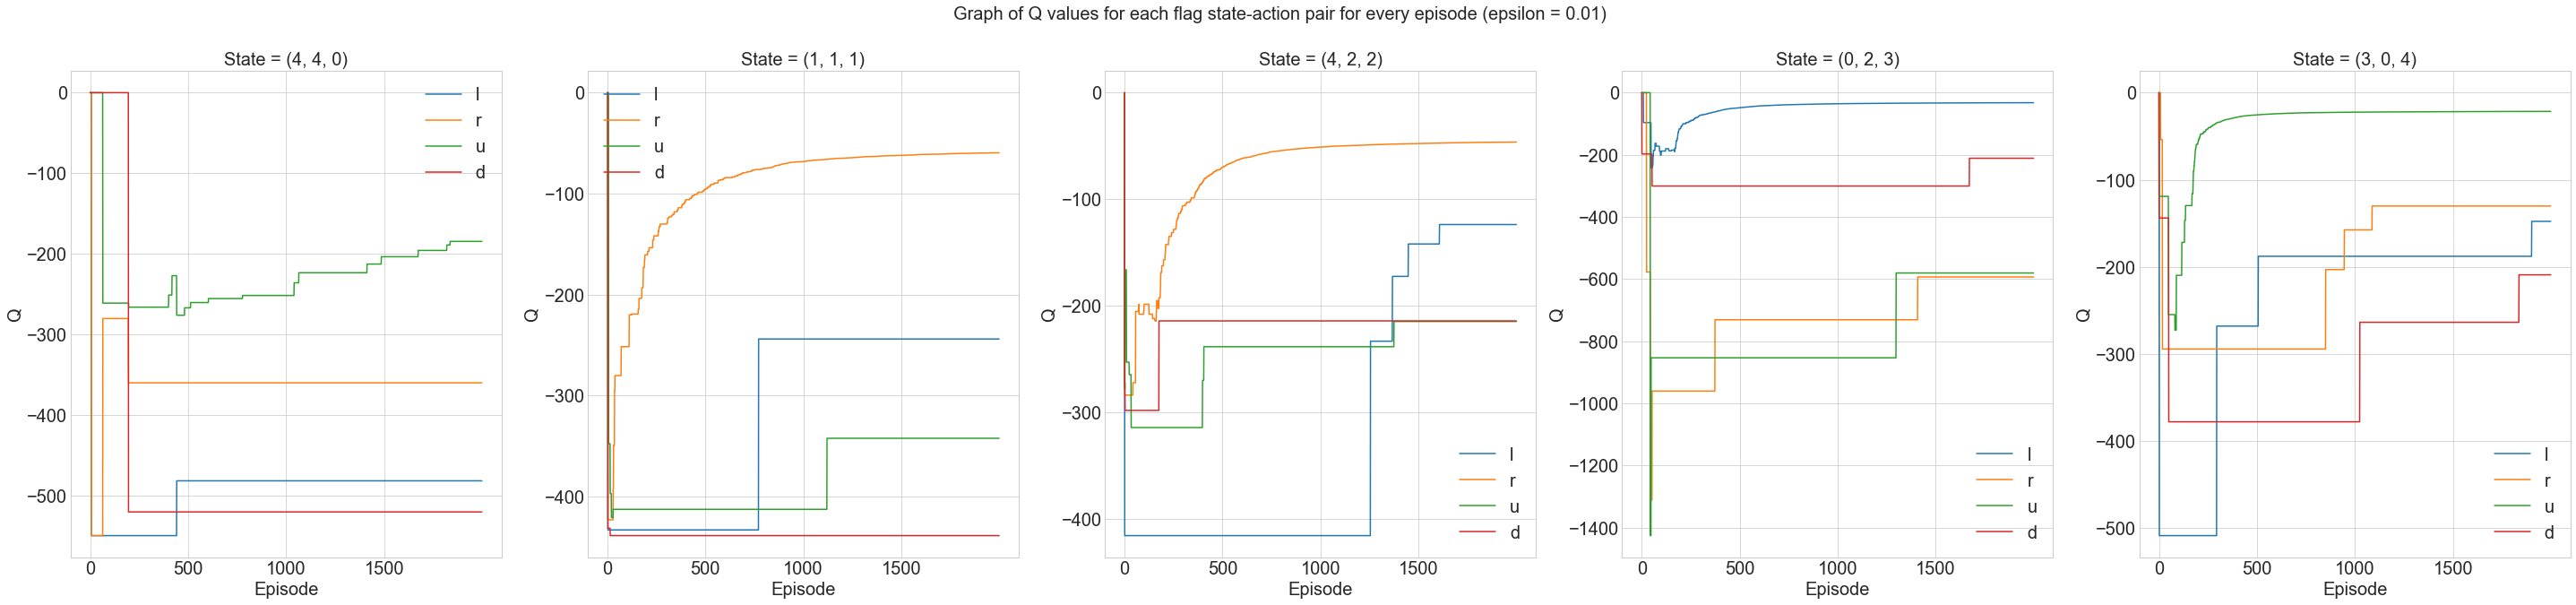

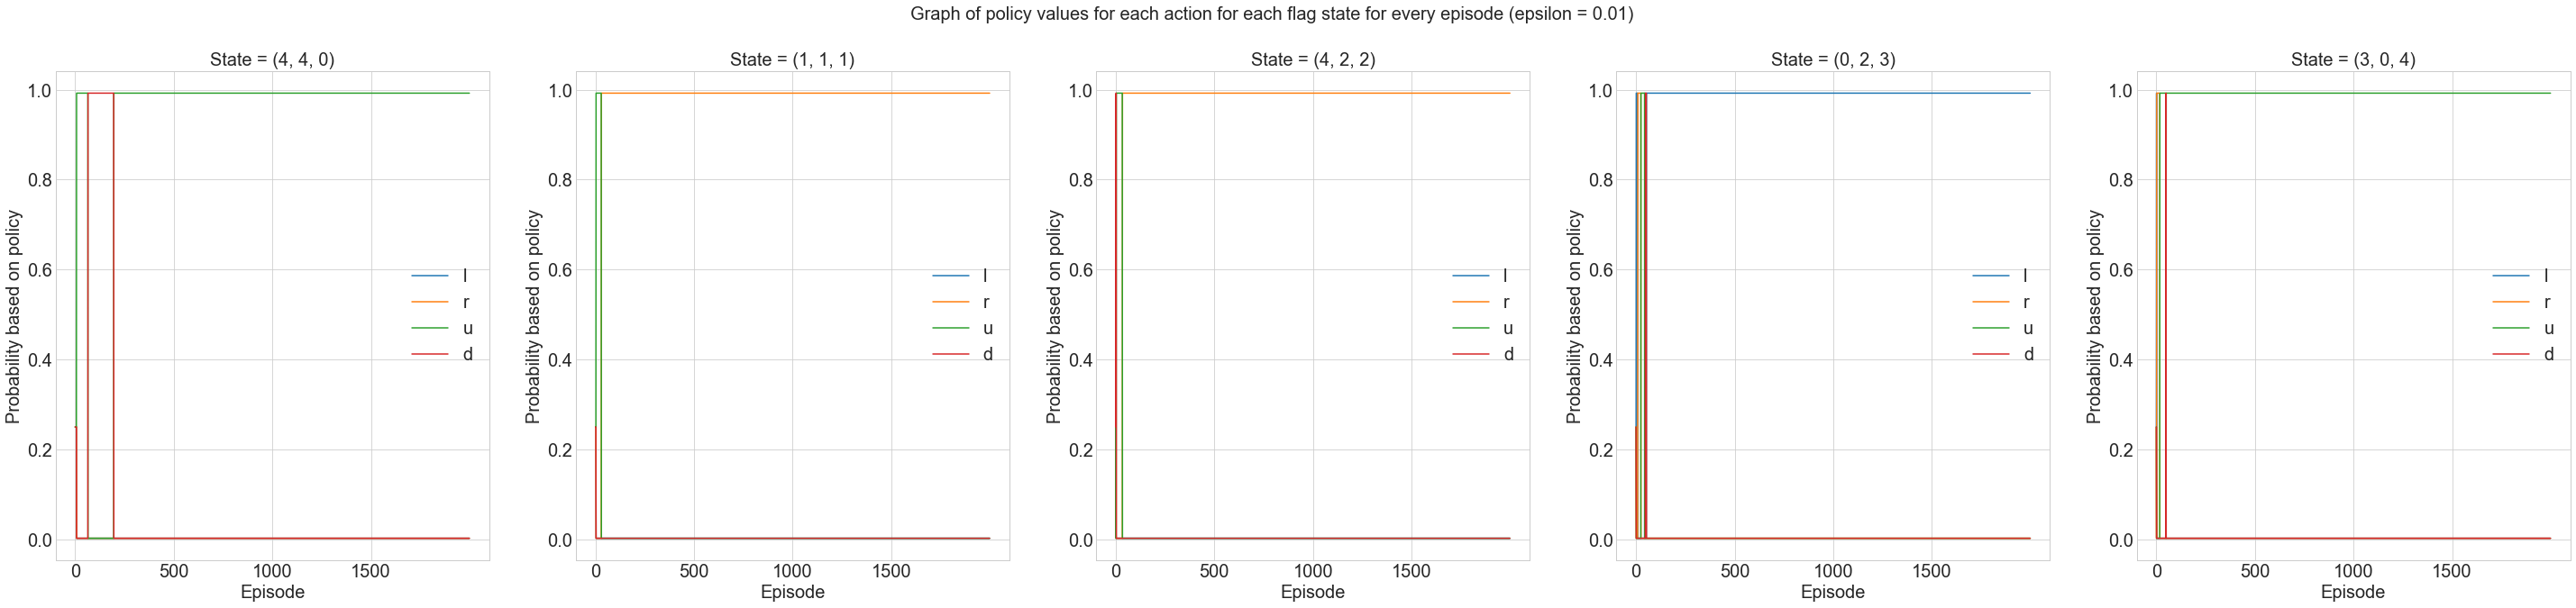

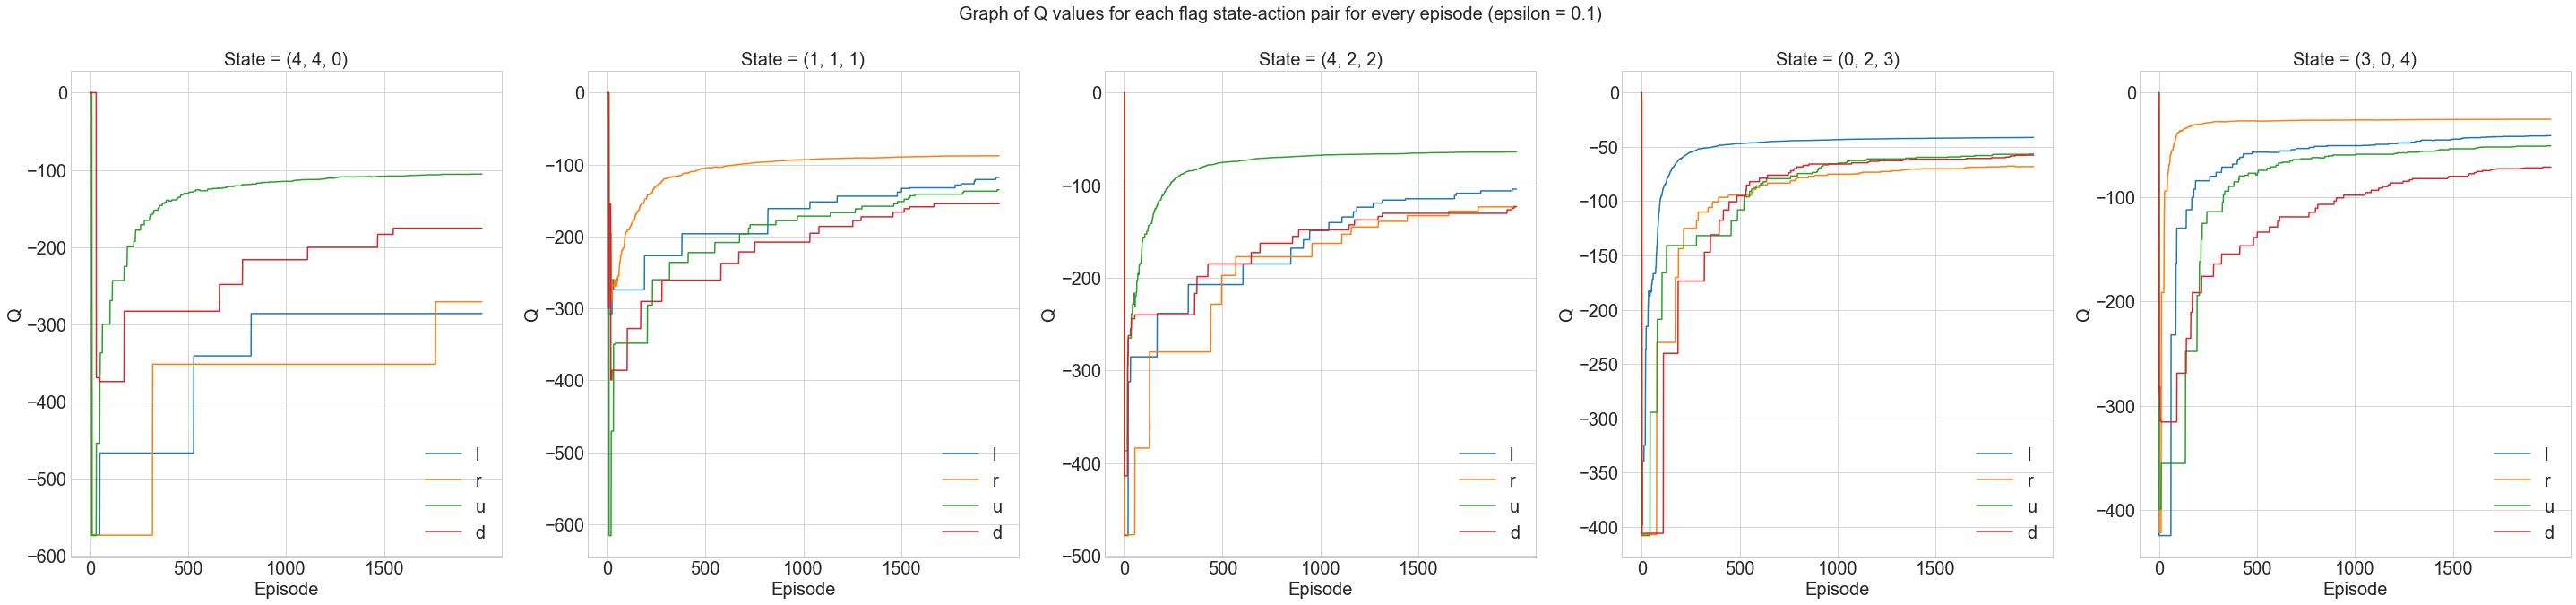

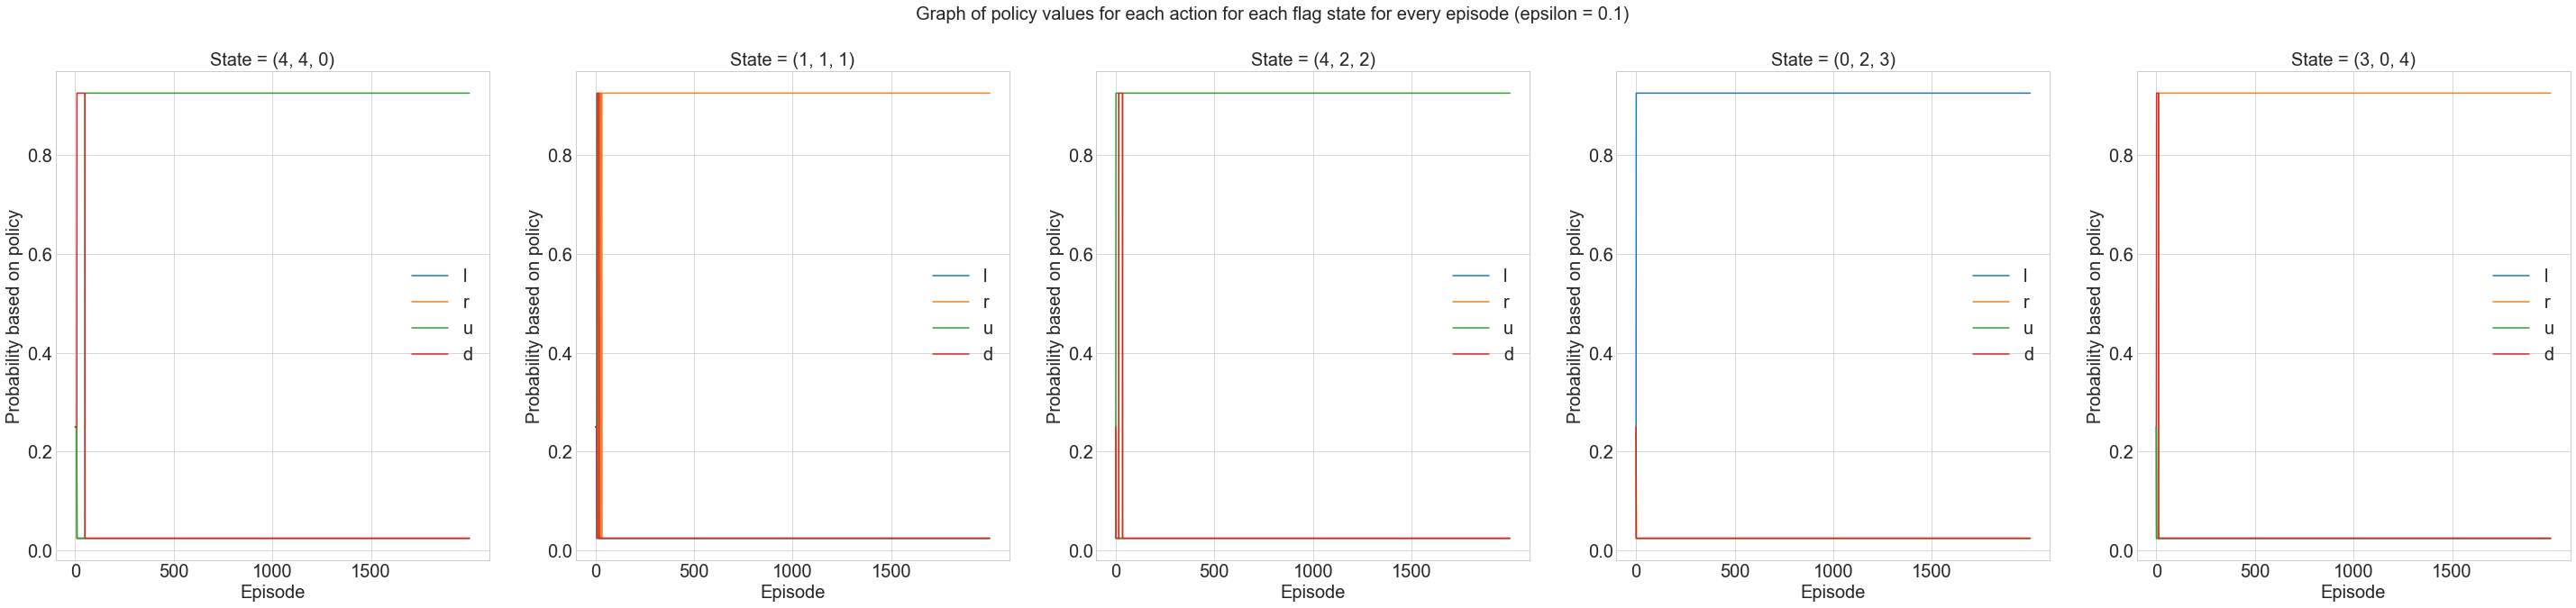

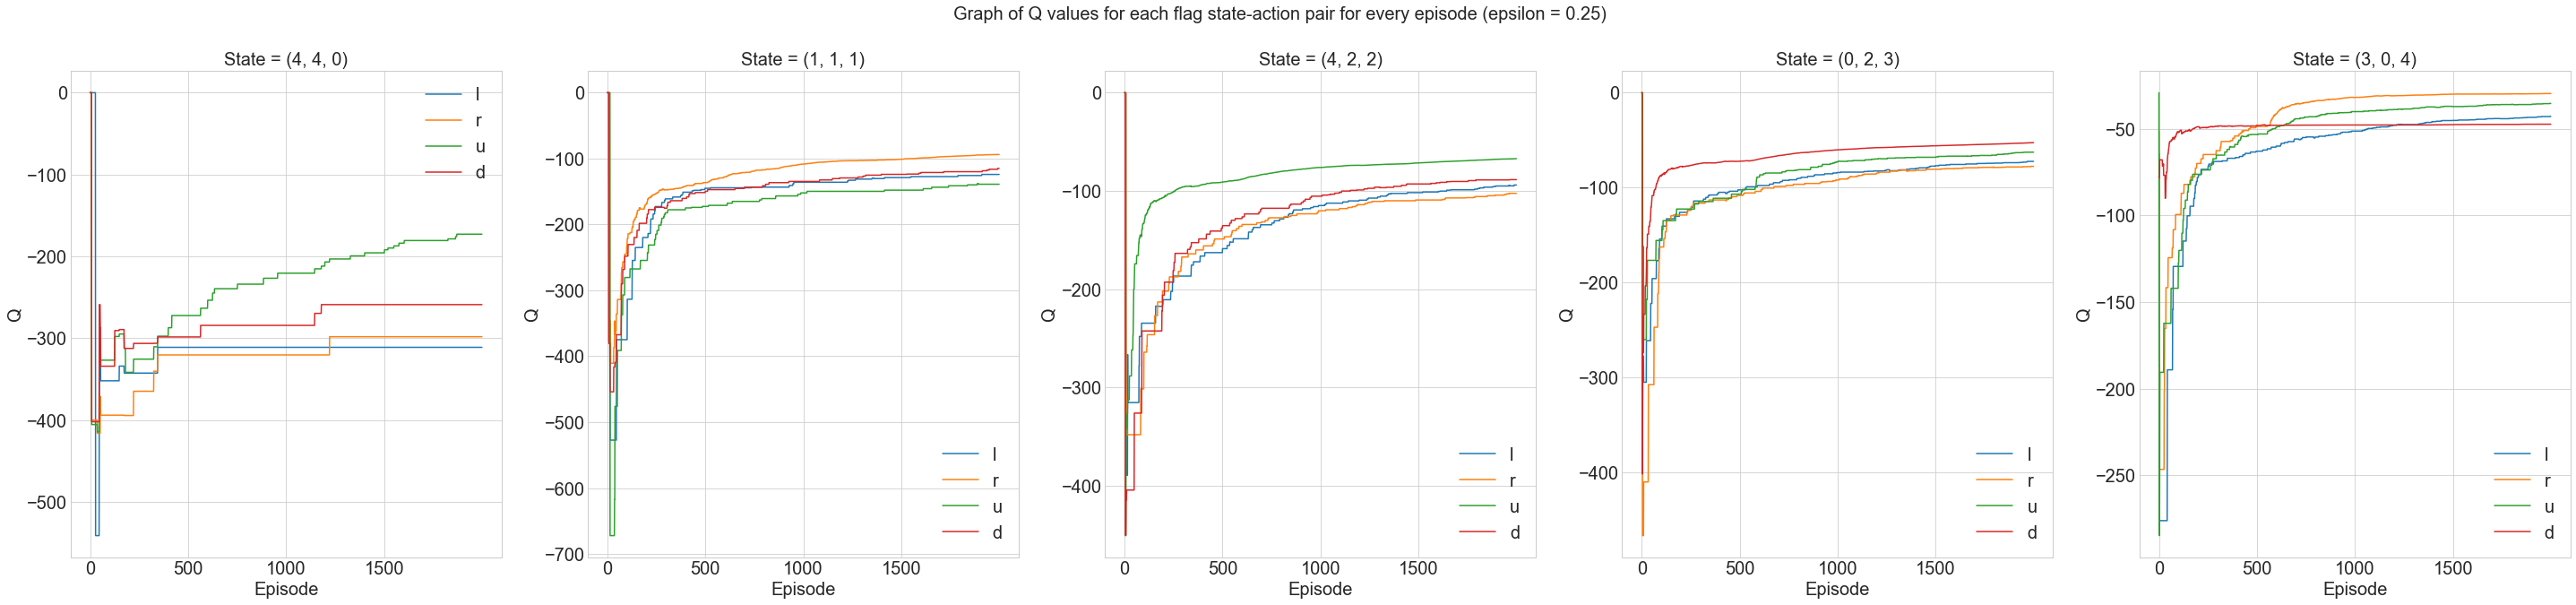

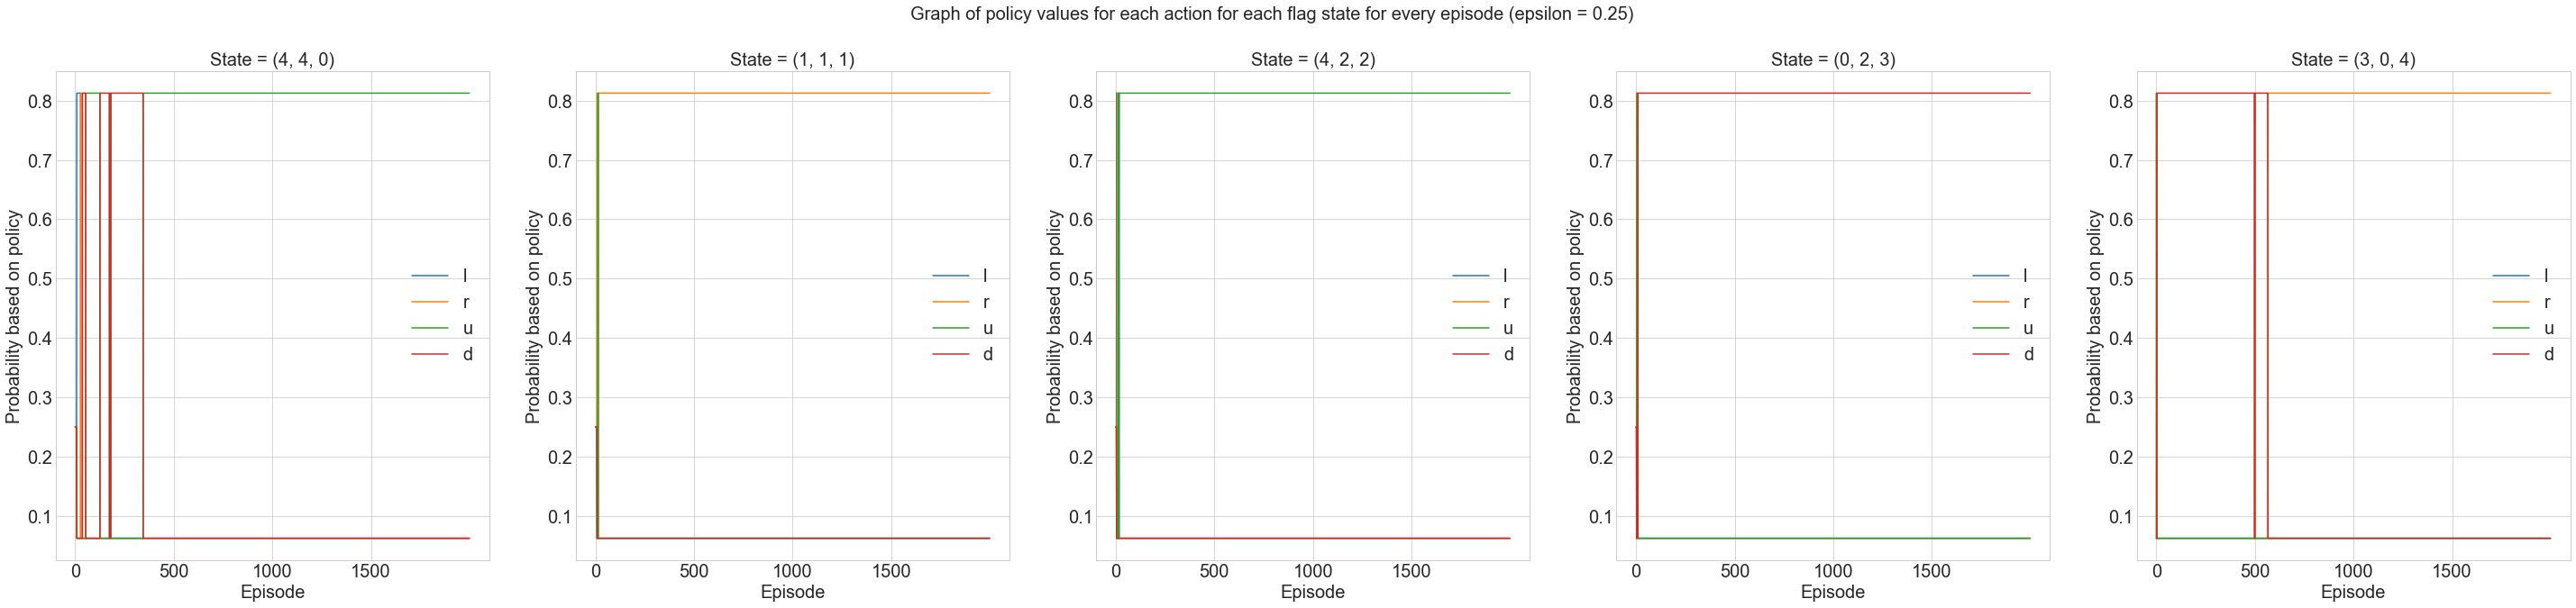

In [120]:
env = Flags()

for epsilon in (0.01, 0.1, 0.25):
    pi, q = first_visit_mc(epsilon, env)
    print(f"Epsilon = {epsilon}")
    print(f"Policy: {pi}")
    print(f"Q: {q}")
    path, _ = follow_policy(env, pi)
    if abs(epsilon - 0.25) < 1e-4: # for Q5
        policy_first_visit_mc = pi
        q_first_visit_mc = q
        path_first_visit_mc = path
    print()

The plots for the Q values (state-action value function) and policy for 5 states are shown above. The 5 states are chosen such that they denote the initial state, and the state where a flag is captured.

Given that the epsilon value denotes the greediness of the policy, we can determine the "best" epsilon by assessing the convergence of Q. Since epsilon determines the policy of each state, we can assess how well the Q-function is estimated for each policy to find the best epsilon. From the Q-graphs, the epsilon value that showed the fastest convergence of Q for all 5 states is epsilon = 0.25. As evident in the graphs, for epsilon = 0.25, the Q-values do not flunctuate too drastically after around 1200 episodes. Also, epsilon = 0.25 reaches the goal state in the shortest path in most instances.

In terms of algorithm convergence, we can assess the convergence of Q values:

- For Epsilon = 0.01, even near the end of the 2000 episodes, it is evident that the Q values are flunctuating and certain Q(s, a) combinations are not converging. 
    
- For Epsilon = 0.1, the Q values seem to be converging better. After 1500 episodes, the Q values do not have drastic changes and seem to be oscillating only slightly. 

- For Epsilon = 0.25, the Q values show the best convergence. For certain states, the Q values converge after 1000 episodes, and are nearly horizontally linear at the end of the 2000 episodes. 

Please see the print statements above the graph for the policy and state-value function (Q) estimation after 2000 episodes.

In terms of completeness, all 3 epsilon values result in the robot reaching the goal state, so they are all complete. 

In terms of optimality, althought the Q values converge, the total length of the path is larger than 26 - thus it is not optimal. However, it is evident that it is close to optimality as it ranges between 26 to 40 in most trials.

- For Epsilon = 0.01, the length of the path found is generally above 30 but less than 40 (pattern found after running the code cell multiple times).

- For Epsilon = 0.1, the length of the path tends to be between 28 and 40.

- For Epsilon = 0.25, in most instances; this epsilon value has the shortest path length. After running the code block several times, the smallest observed value was 28 and the highest was 38.

The path lengths observed may flunctuate (with changes in hyperparameters), but since all three epsilons do not reach the optimal length of 26, none of these methods are optimal. However, considering all of this analysis, it can be seen that epsilon = 0.25 is the best choice for estimating an optimal policy and Q function.


3.3. Consider a random behavior policy $b(a|s)=1/|A|$ for every state and action. Use episodes generated with $b$ to find the approximate optimal policy $\pi^*$. First use ordinary importance sampling Monte Carlo control. Then use weighted importance sampling Monte Carlo control. Answer the same questions as in 3.2.  [15 Marks]

In [121]:
# 3.3 - Off-policy Monte Carlo

def off_policy_mc(ratio_type: str, env: Flags):
    if ratio_type not in ["WIS", "OIS"]:
        raise ValueError("Invalid Importance Sampling Type. Please enter 'WIS' for weighted or 'OIS' for ordinary")
    
    gamma = 0.99
    all_states = env.states_space()

    # initialize
    policy = {state: 'l' for state in all_states} # deterministic policy since initialized as argmax
    q = {(state, action): 0 for state in all_states for action in env.actions_space(state)} 
    c = {(state, action): 0 for state in all_states for action in env.actions_space(state)} 
    b = {state: [1/len(env.actions_space(state))]*len(env.actions_space(state)) for state in all_states} # behaviour policy

    # storing values for plotting
    monitoring_states = [(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]
    graph_q_values = {}
    graph_policy = {}

    k = 2000

    for _ in range(k):
        # choose a random state
        rand_state = random.choice(all_states)

        # choose a random action based on the behaviour policy of the random state
        rand_action = random.choices(env.actions_space(rand_state), weights=b[rand_state])[0]

        # generate episode using behaviour policy
        state_ep, action_ep, reward_ep = generate_episode(rand_state, rand_action, b, env)
        g = 0
        w = 1
        for t in range(len(state_ep)-1, -1, -1):
            curr_state, curr_action = state_ep[t], action_ep[t]
            g = (gamma * g) + reward_ep[t]
            c[(curr_state, curr_action)] = c[(curr_state, curr_action)] + w if ratio_type == "WIS" else c[(curr_state, curr_action)] + 1
            q[(curr_state, curr_action)] = q[(curr_state, curr_action)] + ((w / c[(curr_state, curr_action)]) * (g - q[(curr_state, curr_action)])) if ratio_type == "WIS" \
                else q[(curr_state, curr_action)] + ((1 / c[(curr_state, curr_action)]) * (w*g - q[(curr_state, curr_action)]))
            
            best_q, best_action = float("-inf"), policy[curr_state]
            for action in env.actions_space(curr_state):
                if q[(curr_state, action)] > best_q:
                    best_q = q[(curr_state, action)]
                    best_action = action

            policy[curr_state] = best_action

            if curr_action != best_action:
                break

            w *= len(env.actions_space(curr_state))

        # for graphing
        for state in monitoring_states:
            for i, action in enumerate(env.actions_space(state)):
                if (state, action) not in graph_q_values:
                    graph_q_values[(state, action)] = [q[(state, action)]]
                else:
                    graph_q_values[(state, action)].append(q[(state, action)])
                
                if (state, action) not in graph_policy:
                    graph_policy[(state, action)] = [policy[state]]
                else:
                    graph_policy[(state, action)].append(policy[state])
    
    create_plots(env, graph_q_values, graph_policy, sampling_type=ratio_type, epoch=k)

    return policy, q

Type = WIS
Policy: {(2, 0, 2): 'r', (4, 0, 4): 'r', (0, 1, 0): 'l', (4, 0, 1): 'l', (2, 1, 3): 'l', (0, 3, 3): 'l', (4, 4, 4): 'd', (3, 2, 1): 'l', (1, 3, 3): 'l', (1, 4, 2): 'l', (1, 3, 0): 'r', (3, 4, 4): 'u', (3, 3, 2): 'l', (0, 0, 1): 'd', (4, 1, 2): 'r', (1, 0, 1): 'r', (2, 3, 3): 'l', (0, 2, 4): 'r', (0, 4, 1): 'r', (3, 0, 0): 'l', (2, 0, 1): 'l', (4, 0, 3): 'r', (4, 2, 0): 'l', (0, 3, 2): 'l', (4, 4, 3): 'l', (3, 1, 1): 'l', (3, 2, 0): 'l', (1, 4, 4): 'u', (1, 3, 2): 'l', (3, 3, 4): 'l', (0, 0, 3): 'd', (4, 1, 4): 'd', (4, 3, 1): 'l', (0, 0, 0): 'l', (0, 2, 0): 'l', (4, 1, 1): 'l', (1, 1, 2): 'd', (1, 0, 0): 'l', (2, 4, 4): 'u', (0, 4, 3): 'l', (3, 0, 2): 'r', (2, 0, 3): 'l', (2, 2, 0): 'l', (0, 1, 1): 'd', (4, 2, 2): 'u', (1, 2, 0): 'l', (0, 3, 4): 'r', (3, 1, 3): 'u', (3, 2, 2): 'l', (3, 1, 0): 'l', (1, 3, 4): 'r', (1, 4, 3): 'l', (2, 4, 0): 'l', (0, 0, 2): 'l', (4, 1, 3): 'l', (4, 3, 0): 'l', (1, 1, 4): 'd', (1, 0, 2): 'd', (1, 1, 1): 'u', (3, 0, 4): 'u', (2, 2, 2): 'u', (2, 

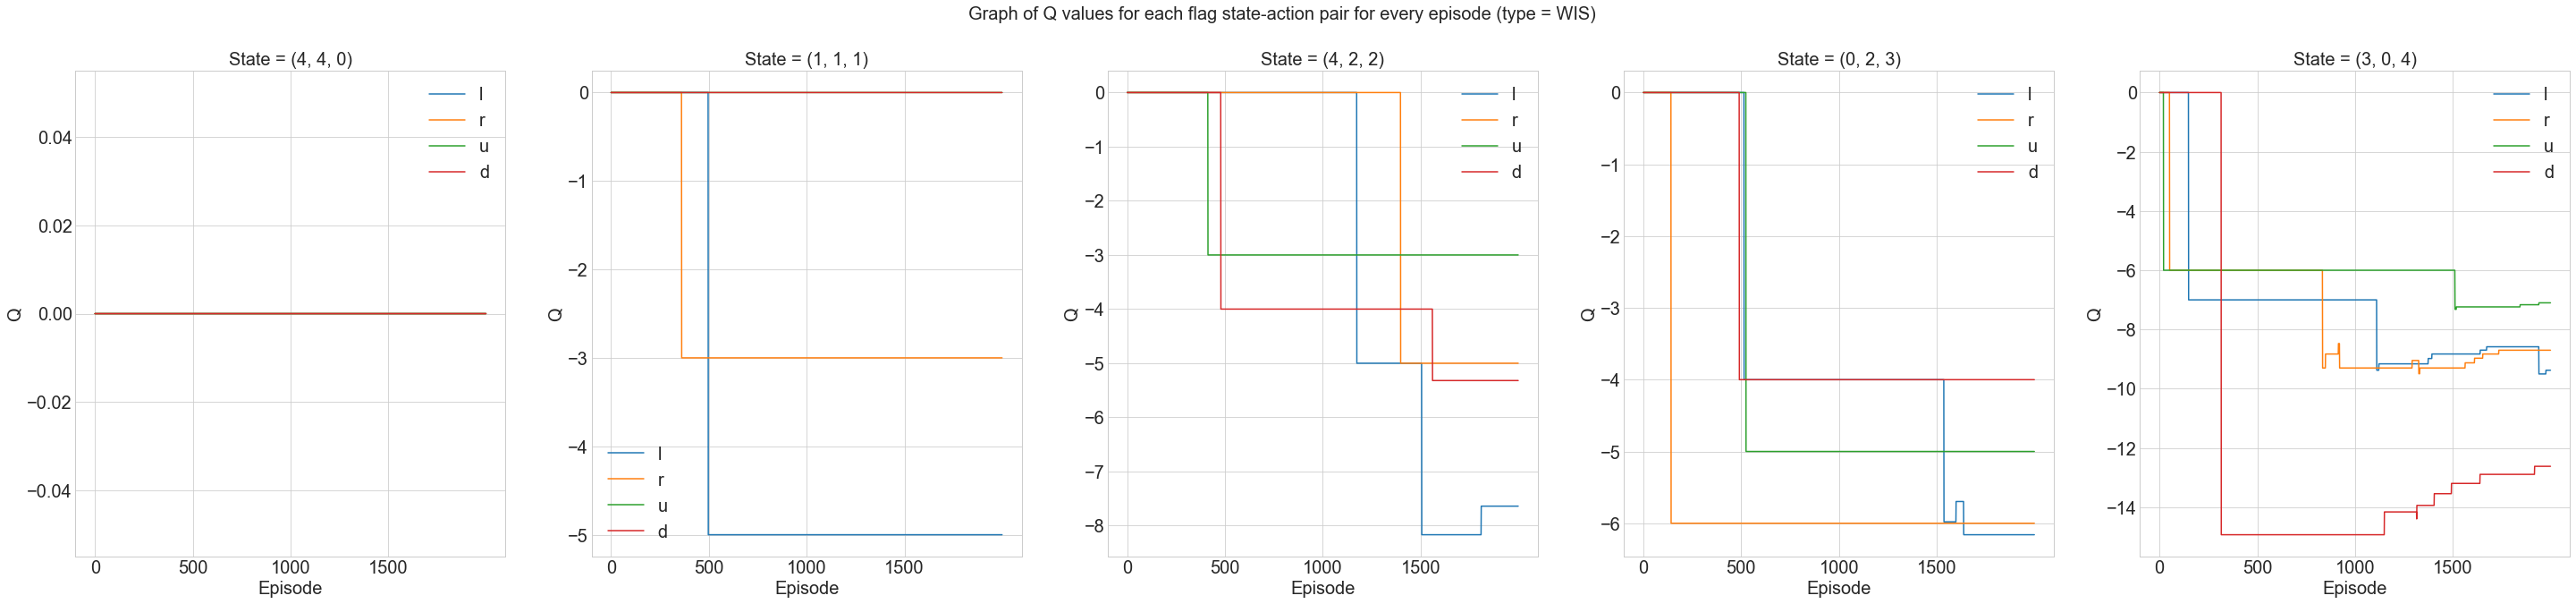

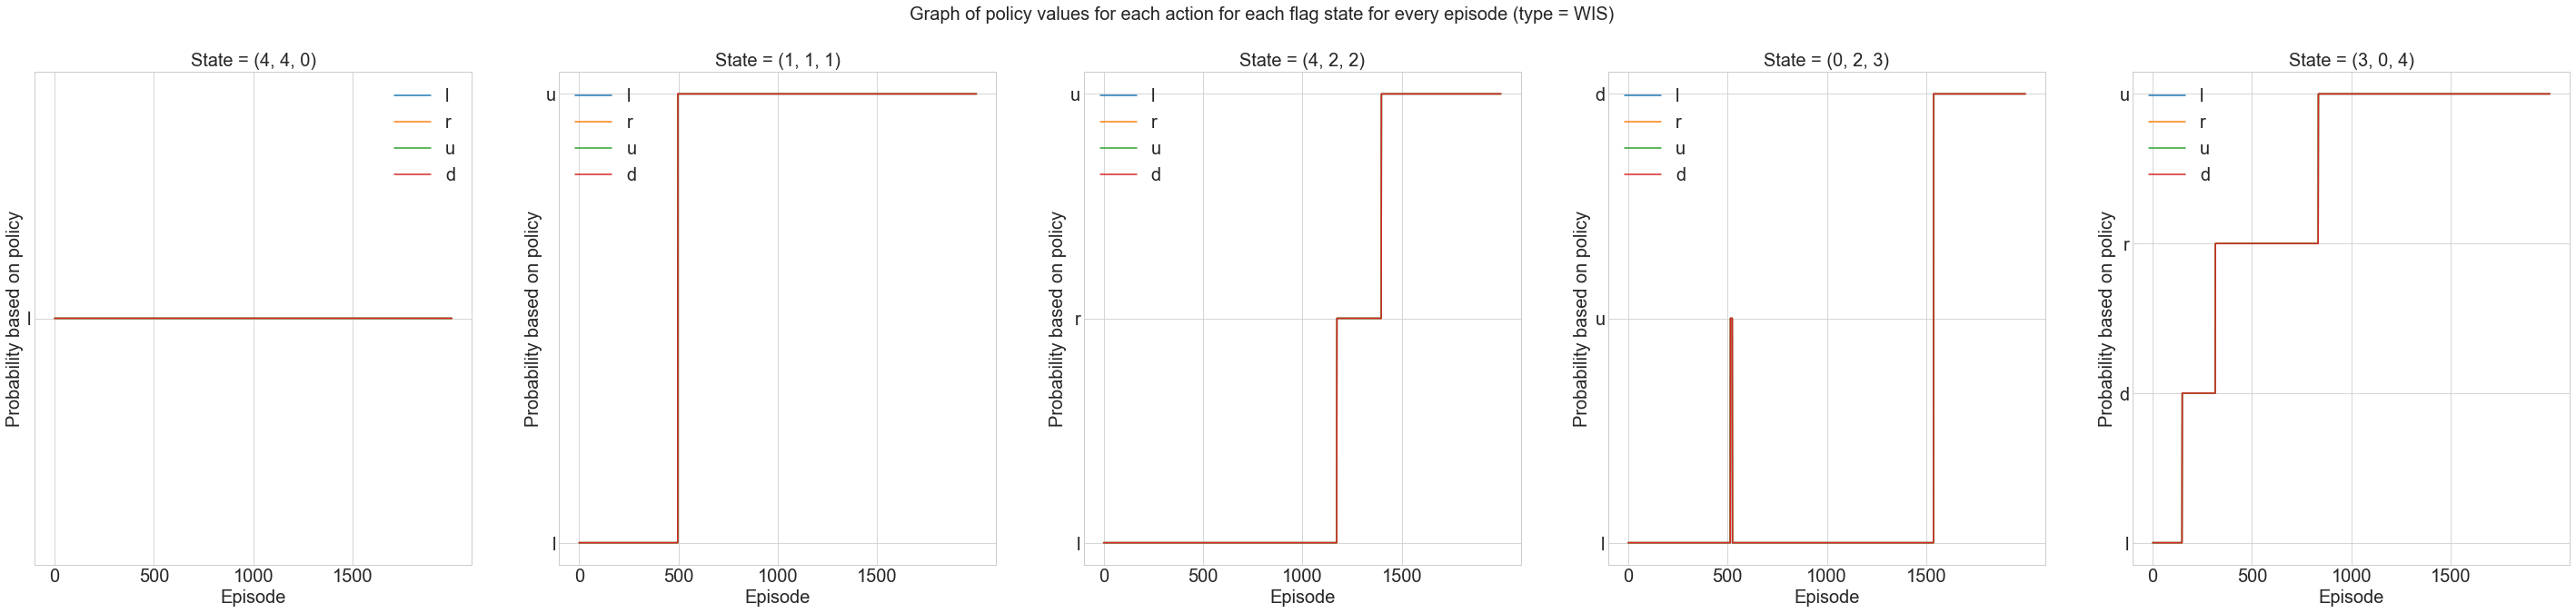

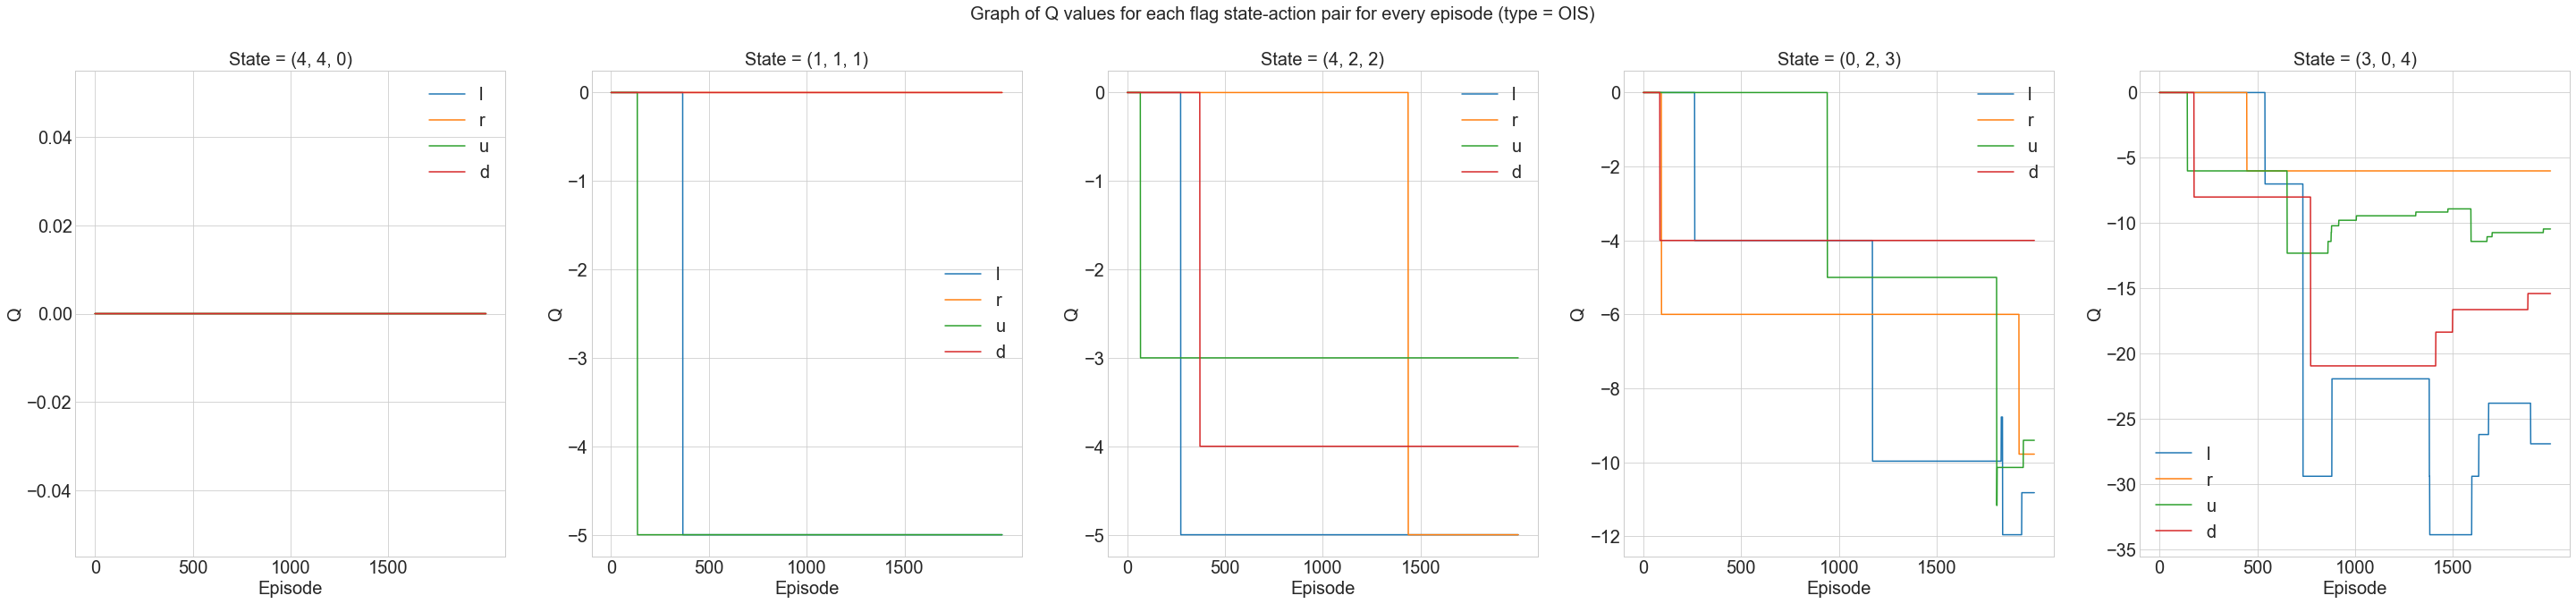

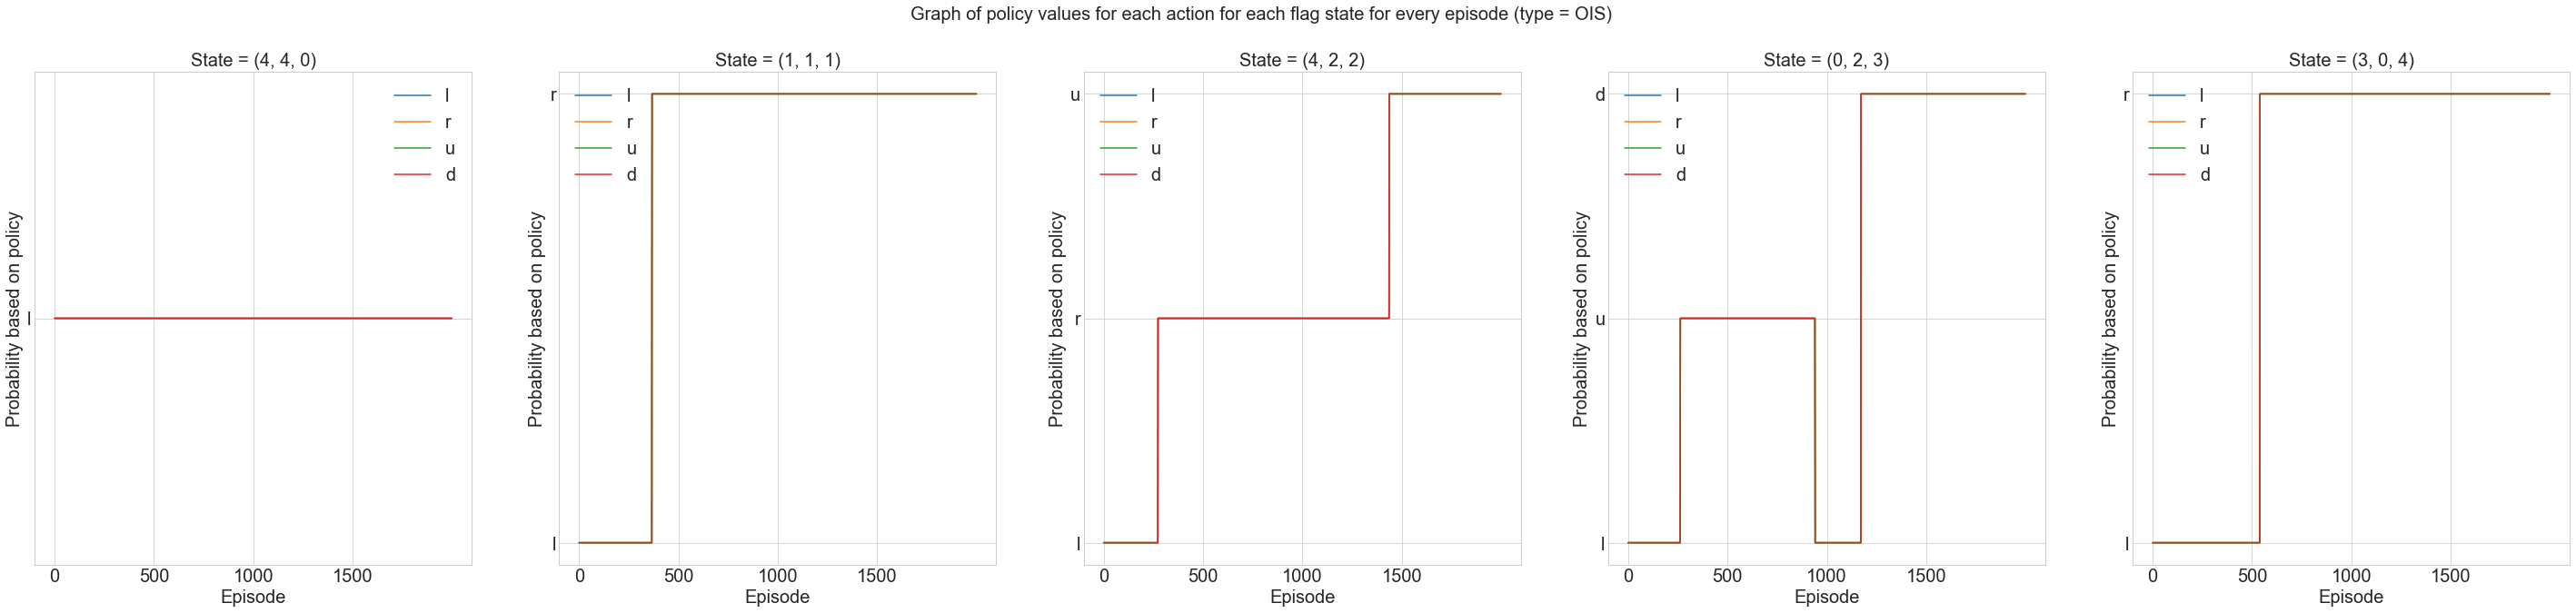

In [123]:
env = Flags()

for ratio_type in ("WIS", "OIS"):
    pi, q = off_policy_mc(ratio_type, env)
    print(f"Type = {ratio_type}")
    print(f"Policy: {pi}")
    print(f"Q: {q}")
    path, _ = follow_policy(env, pi, off_policy=True)
    if ratio_type == "WIS":
        policy_off_policy_mc = pi
        q_off_policy_mc = q
        path_off_policy_mc = path
    print()

From the Q action-value function graphs, it is evident that WIS achieves better convergence near the end of the 2000 episodes. For OIS, there is significant oscillation of Q-values even at the later episodes which means that the learning is not stabilized as much as WIS. This is an indication that WIS is a better and more stable ratio to use for off-policy monte carlo learning methods.

In terms of convergence, for WIS, the Q-values are horizontal and do not display major flunctuations. For OIS, certain states display stepwise movement of the Q-values. It is evident that the WIS ratio type results in better convergence of the Q-values than OIS.

For the estimated Q function and policy, please see the print statements above the graph.

In terms of the optimality of the policy, none of the two methods - when using the given behaviour function - are optimal. In fact, the policy is not complete either. For these two methods of off-policy importance sampling, the agent unfortunately does not reach the goal state. Even after increasing the number of episodes to larger values like 5000 and even 10000, the goal state is never reached. After attempting to debug by printing the agent's movement, it was found that certain states where the robot is on the grid's boundary have a deterministic policy that moves it towards the edge of the boundary, which forces the agent to stay in the same cell. Since the policy is deterministic, the agent keeps on repeating the same move and continues to stay in the same cell. This does not move the agent and causes an infinite loop - which ultimately means that the agent does not escape from that cell to progress to its next flag/goal. We believe that the source of this issue is due to improper rewards generated for this off-policy method. If the rewards are not proper, then the Q-function will not update properly for each state-action pair, which will cause deterministic policies to not update for certain states. This may cause the behaviour that we see where the agent consistenly repeats the same action and does not move from its current cell. 


### 4 Temporal Diference Control Methods [25 Marks]

In this section, you are asked to implement SARSA and Q-learning methods to solve the flags domain. Use a discount factor of $\gamma= 0.99$ and a learning rate of $\alpha = 0.3$ for all your experiments.Set the maximum length of each episode to 200 if the terminal state is not reached by this point.Training should proceed for a total of 500 episodes.

4.1. Implement the off-policy Q-learning algorithm as discussed in class. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and  answer the same questions as in 3.2. [13 Marks]

In [124]:
def create_plots_TD(env, q_history, policy_history, epsilon, save_plots=False):
    """
    Plot Q-values and policy evolution over episodes with enhanced formatting.

    Args:
        env: The environment
        q_history: History of Q-values
        policy_history: History of policy values
        epsilon: Exploration parameter
        save_plots: Whether to save plots to files (default: False)
    """

    # Set style for better visuals
    plt.style.use("seaborn-v0_8-whitegrid")

    # Plot Q-value evolution
    fig1, axes1 = plt.subplots(1, 5, figsize=(20, 6), sharey=True)
    fig1.suptitle(f"Q-values Evolution (ε = {epsilon})", fontsize=16)
    fig1.tight_layout(pad=3.0)

    # Color cycle for better action differentiation
    colors = plt.cm.tab10.colors

    for i, state in enumerate(q_history.keys()):
        for j, action in enumerate(q_history[state]):
            axes1[i].plot(
                range(len(q_history[state][action])),
                q_history[state][action],
                label=f"Action: {action}",
                color=colors[j % len(colors)],
                linewidth=2,
            )
        axes1[i].set_xlabel("Episode", fontsize=12)
        if i == 0:  # Only set y-label on the first subplot
            axes1[i].set_ylabel("Q-value", fontsize=12)
        axes1[i].set_title(f"State {state}", fontsize=12)
        axes1[i].legend(fontsize=10)
        axes1[i].grid(True, alpha=0.3)

    # Plot policy evolution
    fig2, axes2 = plt.subplots(1, 5, figsize=(20, 6), sharey=True)
    fig2.suptitle(f"Policy Evolution (ε = {epsilon})", fontsize=16)
    fig2.tight_layout(pad=3.0)

    for i, state in enumerate(policy_history.keys()):
        for j, action in enumerate(policy_history[state]):
            axes2[i].plot(
                range(len(policy_history[state][action])),
                policy_history[state][action],
                label=f"Action: {action}",
                color=colors[j % len(colors)],
                linewidth=2,
            )
        axes2[i].set_xlabel("Episode", fontsize=12)
        if i == 0:  # Only set y-label on the first subplot
            axes2[i].set_ylabel("Action Probability", fontsize=12)
        axes2[i].set_title(f"State {state}", fontsize=12)
        axes2[i].legend(fontsize=10)
        axes2[i].grid(True, alpha=0.3)

    # Save plots if requested
    if save_plots:
        fig1.savefig(f"q_values_epsilon_{epsilon}.png", dpi=300, bbox_inches="tight")
        fig2.savefig(f"policy_epsilon_{epsilon}.png", dpi=300, bbox_inches="tight")

    plt.show()


def follow_policy_TD(env, policy, off_policy=False):
    """
    Follow a policy through the environment and report the path.

    Args:
        env: Environment object
        policy: Policy to follow (dict mapping states to actions or action probabilities)
        off_policy: Whether the policy is deterministic (True) or stochastic (False)

    Returns:
        Path length and whether goal was reached
    """
    curr_state = env.init_state
    goal_state = env.goal_state
    path = [curr_state]

    print("\n=== PATH TRACING ===")
    print(f"Starting from state: {curr_state}")
    print(f"Target goal state: {goal_state}")

    while curr_state != goal_state:
        # Select action based on policy type
        if off_policy:
            # Deterministic policy (direct action)
            best_action = policy[curr_state]
        else:
            # Stochastic policy (probability distribution over actions)
            action_probs = policy[curr_state]
            # Find action(s) with maximum probability
            max_prob = max(action_probs.values())
            best_actions = [
                a for a, p in action_probs.items() if abs(p - max_prob) < 1e-6
            ]
            best_action = best_actions[0]  # Take the first best action

        # Execute action
        next_state, reward = env.transition(curr_state, best_action)

        # Detect cycles
        if next_state in path:
            print(f"\nCycle detected! Revisiting state: {next_state}")
            break

        # Move to next state and record
        curr_state = next_state
        path.append(curr_state)

    # Print results
    path_length = len(path) - 1  # Number of steps (transitions)

    print("\n=== RESULTS ===")
    print(f"Path length: {path_length} steps")
    print("Path taken:")
    for i, state in enumerate(path):
        if i < len(path) - 1:
            print(f"{state} ->", end='')
        else:
            print(f"{state}")

    if curr_state == goal_state:
        print("\nGOAL REACHED SUCCESSFULLY!")
    else:
        print("\nFailed to reach goal. Possible cycle in policy.")

    return path, path_length, curr_state == goal_state

In [125]:
class QLearningAgent:
    def __init__(self, env, alpha=0.3, gamma=0.99, epsilon=0.1, episodes=500, max_steps=200):
        self.env = env
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration probability
        self.episodes = episodes
        self.max_steps = max_steps
        self.q_table = {state: {action: 0.0 for action in env.actions_space(state)} for state in env.states_space()}

        # Track Q-value progression for specific states
        self.q_history = {state: {action: [] for action in env.actions_space(state)} 
                          for state in [(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]}

        # Track best policy choice for specific states
        self.policy_history = {state: {action: [] for action in env.actions_space(state)} 
                               for state in [(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]}

    def get_action_probabilities(self, state):
        """
        Return probability distribution over actions for given state
        based on epsilon-greedy policy
        """
        # Get number of possible actions for this state
        actions = self.env.actions_space(state)
        n_actions = len(actions)

        # Initialize probabilities with the exploration probability
        probs = {a: self.epsilon / n_actions for a in actions}

        # Find action(s) with maximum Q-value
        max_q_value = max(self.q_table[state].values())
        best_actions = [a for a, q in self.q_table[state].items() if q == max_q_value]

        # Distribute the exploitation probability (1-epsilon) among best actions
        for action in best_actions:
            probs[action] += (1.0 - self.epsilon) / len(best_actions)

        return probs

    def choose_action(self, state):
        """Select action using epsilon-greedy policy"""
        action_probs = self.get_action_probabilities(state)

        # Convert to list for sampling
        actions = list(action_probs.keys())
        probs = list(action_probs.values())

        # Choose action based on probability distribution
        return random.choices(actions, weights=probs)[0]

    def train(self):
        for episode in range(self.episodes):
            state = self.env.reset()
            for step in range(self.max_steps):
                action = self.choose_action(state)
                next_state, reward = self.env.transition(state, action)

                # Q-value update
                best_next_action = max(self.q_table[next_state], key=self.q_table[next_state].get)
                self.q_table[state][action] += self.alpha * (reward + self.gamma * self.q_table[next_state][best_next_action] - self.q_table[state][action])

                state = next_state
                if state == self.env.goal_state:
                    break # end episode if goal reached

            for s in self.q_history.keys():
                for a in self.q_history[s].keys():
                    self.q_history[s][a].append(self.q_table[s][a])  # Track Q-value change
                    best_action = max(self.q_table[s], key=self.q_table[s].get)
                    self.policy_history[s][a].append(1 if a == best_action else 0)  # 1 if best action, 0 otherwise

    def get_policy(self):
        """Return the policy as probability distributions over actions for each state"""
        policy = {}
        for state in self.q_table:
            policy[state] = self.get_action_probabilities(state)
        return policy

Epsilon = 0.01

Policy: {(2, 0, 2): {'l': 0.0025, 'r': 0.9924999999999999, 'u': 0.0025, 'd': 0.0025}, (4, 0, 4): {'l': 0.0025, 'r': 0.9924999999999999, 'u': 0.0025, 'd': 0.0025}, (0, 1, 0): {'l': 0.0025, 'r': 0.0025, 'u': 0.9924999999999999, 'd': 0.0025}, (4, 0, 1): {'l': 0.0025, 'r': 0.0025, 'u': 0.0025, 'd': 0.9924999999999999}, (2, 1, 3): {'l': 0.9924999999999999, 'r': 0.0025, 'u': 0.0025, 'd': 0.0025}, (0, 3, 3): {'l': 0.0025, 'r': 0.0025, 'u': 0.9924999999999999, 'd': 0.0025}, (4, 4, 4): {'l': 0.0025, 'r': 0.0025, 'u': 0.9924999999999999, 'd': 0.0025}, (3, 2, 1): {'l': 0.0025, 'r': 0.0025, 'u': 0.0025, 'd': 0.9924999999999999}, (1, 3, 3): {'l': 0.9924999999999999, 'r': 0.0025, 'u': 0.0025, 'd': 0.0025}, (1, 4, 2): {'l': 0.0025, 'r': 0.9924999999999999, 'u': 0.0025, 'd': 0.0025}, (1, 3, 0): {'l': 0.9924999999999999, 'r': 0.0025, 'u': 0.0025, 'd': 0.0025}, (3, 4, 4): {'l': 0.0025, 'r': 0.0025, 'u': 0.9924999999999999, 'd': 0.0025}, (3, 3, 2): {'l': 0.0025, 'r': 0.0025, 'u': 0.992499

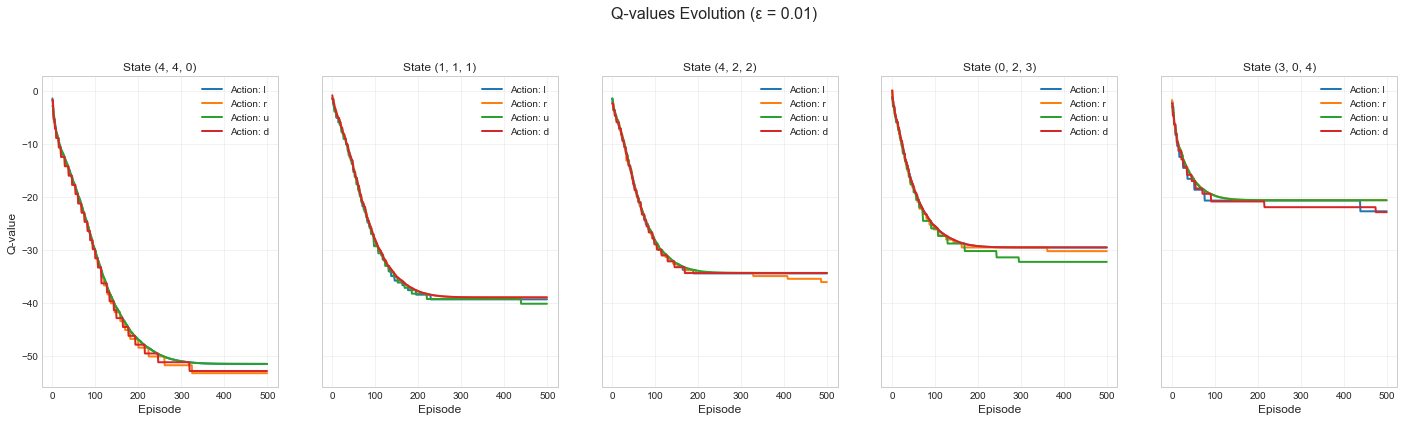

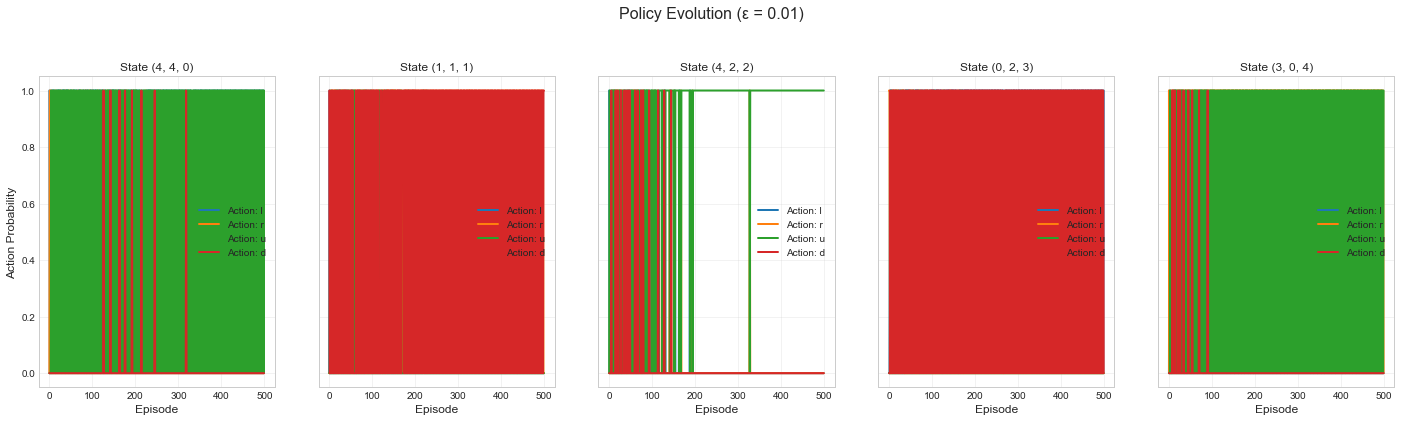

Epsilon = 0.1

Policy: {(2, 0, 2): {'l': 0.025, 'r': 0.025, 'u': 0.925, 'd': 0.025}, (4, 0, 4): {'l': 0.925, 'r': 0.025, 'u': 0.025, 'd': 0.025}, (0, 1, 0): {'l': 0.025, 'r': 0.025, 'u': 0.925, 'd': 0.025}, (4, 0, 1): {'l': 0.025, 'r': 0.925, 'u': 0.025, 'd': 0.025}, (2, 1, 3): {'l': 0.025, 'r': 0.025, 'u': 0.025, 'd': 0.925}, (0, 3, 3): {'l': 0.025, 'r': 0.025, 'u': 0.025, 'd': 0.925}, (4, 4, 4): {'l': 0.025, 'r': 0.025, 'u': 0.925, 'd': 0.025}, (3, 2, 1): {'l': 0.025, 'r': 0.025, 'u': 0.025, 'd': 0.925}, (1, 3, 3): {'l': 0.025, 'r': 0.025, 'u': 0.025, 'd': 0.925}, (1, 4, 2): {'l': 0.925, 'r': 0.025, 'u': 0.025, 'd': 0.025}, (1, 3, 0): {'l': 0.925, 'r': 0.025, 'u': 0.025, 'd': 0.025}, (3, 4, 4): {'l': 0.025, 'r': 0.025, 'u': 0.925, 'd': 0.025}, (3, 3, 2): {'l': 0.025, 'r': 0.925, 'u': 0.025, 'd': 0.025}, (0, 0, 1): {'l': 0.025, 'r': 0.925, 'u': 0.025, 'd': 0.025}, (4, 1, 2): {'l': 0.025, 'r': 0.025, 'u': 0.925, 'd': 0.025}, (1, 0, 1): {'l': 0.025, 'r': 0.925, 'u': 0.025, 'd': 0.025}, 

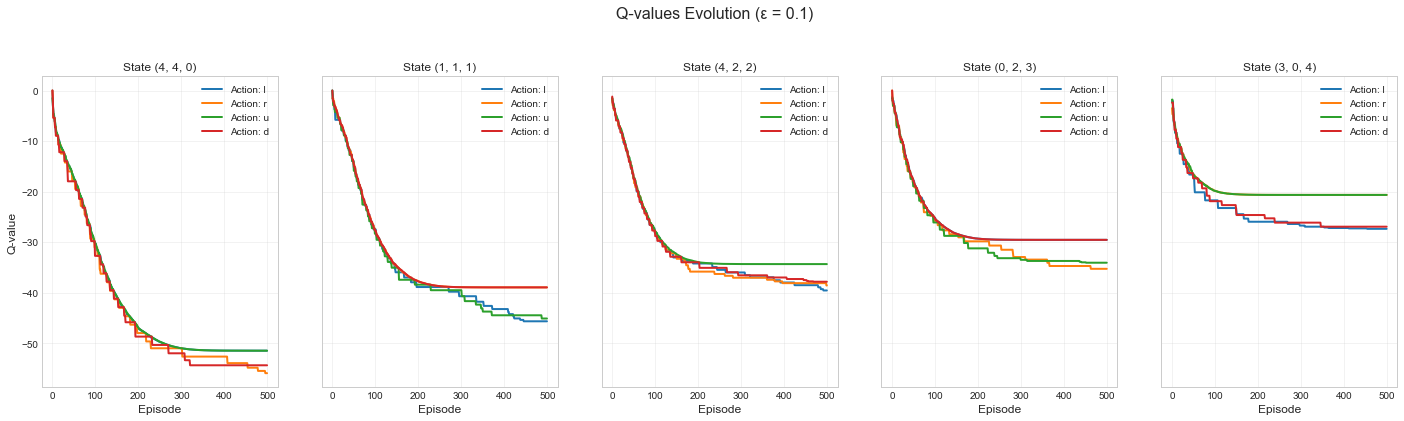

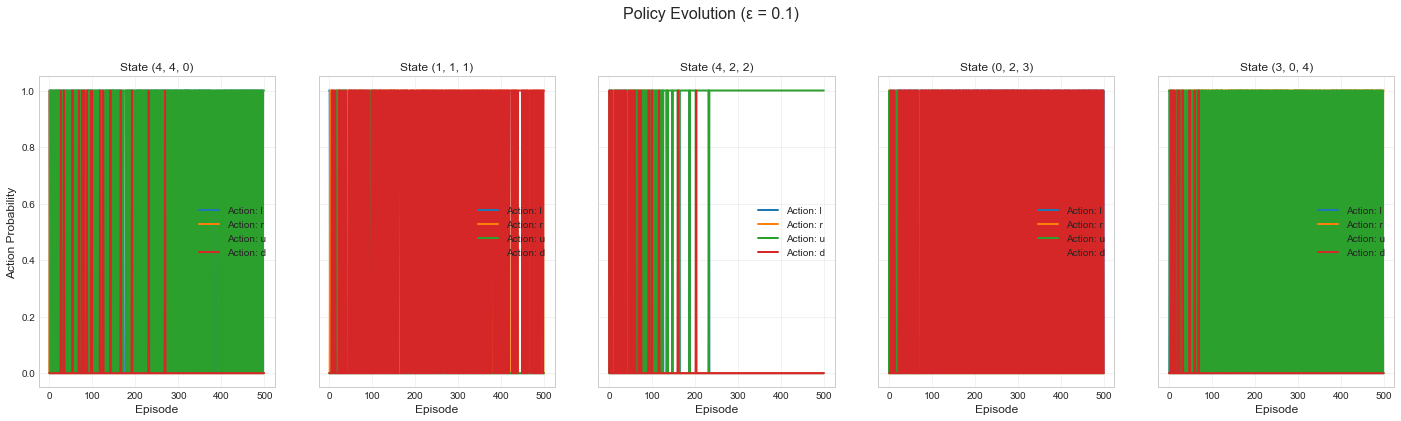

Epsilon = 0.25

Policy: {(2, 0, 2): {'l': 0.0625, 'r': 0.8125, 'u': 0.0625, 'd': 0.0625}, (4, 0, 4): {'l': 0.0625, 'r': 0.0625, 'u': 0.8125, 'd': 0.0625}, (0, 1, 0): {'l': 0.0625, 'r': 0.0625, 'u': 0.8125, 'd': 0.0625}, (4, 0, 1): {'l': 0.0625, 'r': 0.8125, 'u': 0.0625, 'd': 0.0625}, (2, 1, 3): {'l': 0.0625, 'r': 0.0625, 'u': 0.0625, 'd': 0.8125}, (0, 3, 3): {'l': 0.0625, 'r': 0.0625, 'u': 0.0625, 'd': 0.8125}, (4, 4, 4): {'l': 0.0625, 'r': 0.0625, 'u': 0.8125, 'd': 0.0625}, (3, 2, 1): {'l': 0.0625, 'r': 0.0625, 'u': 0.0625, 'd': 0.8125}, (1, 3, 3): {'l': 0.0625, 'r': 0.0625, 'u': 0.0625, 'd': 0.8125}, (1, 4, 2): {'l': 0.8125, 'r': 0.0625, 'u': 0.0625, 'd': 0.0625}, (1, 3, 0): {'l': 0.8125, 'r': 0.0625, 'u': 0.0625, 'd': 0.0625}, (3, 4, 4): {'l': 0.0625, 'r': 0.0625, 'u': 0.8125, 'd': 0.0625}, (3, 3, 2): {'l': 0.0625, 'r': 0.0625, 'u': 0.8125, 'd': 0.0625}, (0, 0, 1): {'l': 0.0625, 'r': 0.0625, 'u': 0.8125, 'd': 0.0625}, (4, 1, 2): {'l': 0.0625, 'r': 0.0625, 'u': 0.8125, 'd': 0.0625}, 

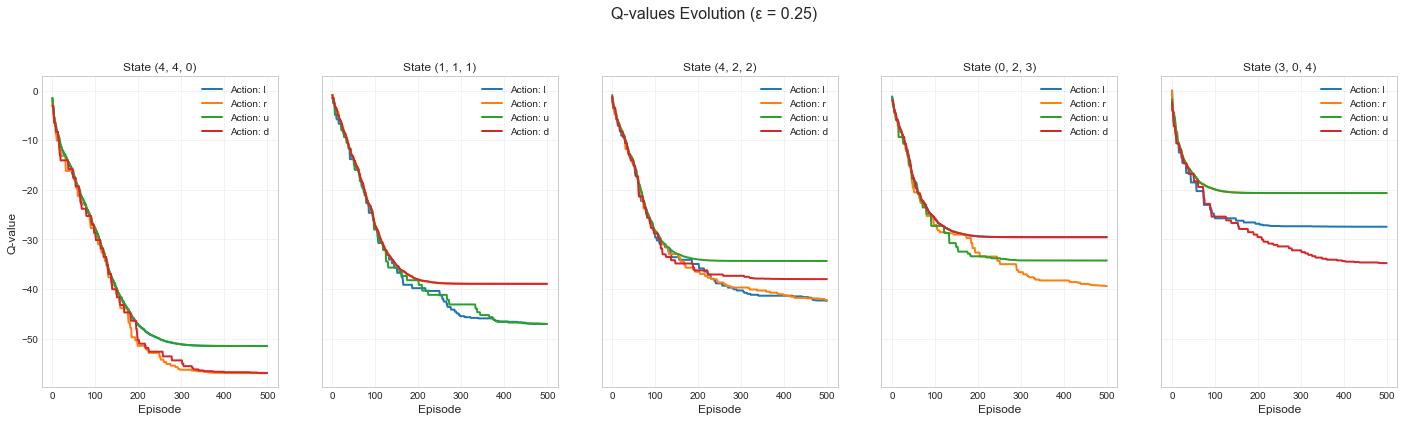

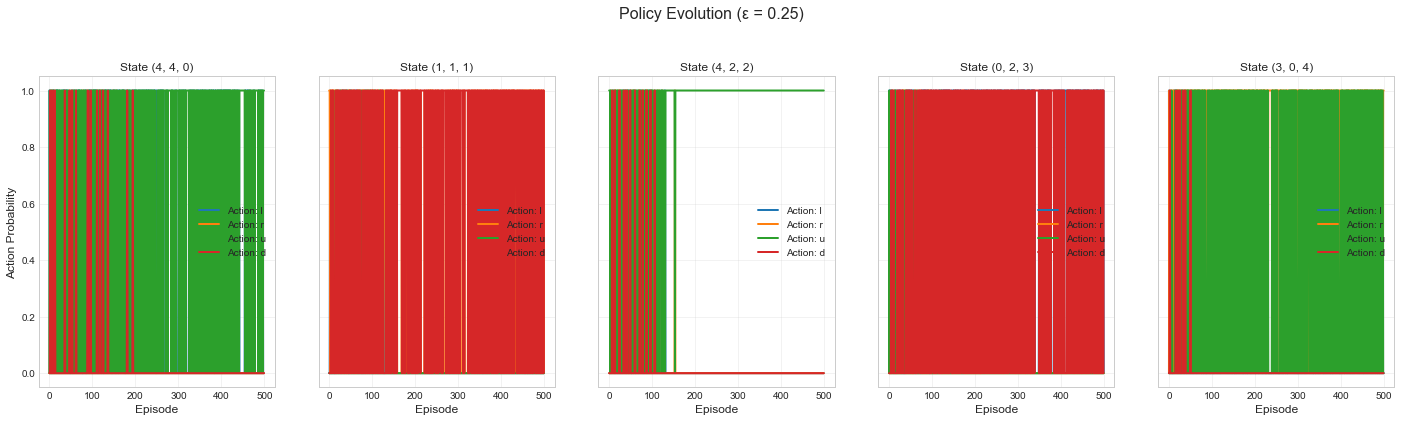

In [126]:
for epsilon in (0.01, 0.1, 0.25):
    env = Flags()
    q_learning = QLearningAgent(env, epsilon=epsilon)
    q_learning.train()
    policy = q_learning.get_policy()
    print(f"Epsilon = {epsilon}\n")
    print(f"Policy: {policy}\n")
    print(f"Q: {q_learning.q_table}\n")
    path, _, _ = follow_policy_TD(env, policy)
    create_plots_TD(env, q_learning.q_history, q_learning.policy_history, q_learning.epsilon)

    if abs(epsilon - 0.01) < 1e-4:
        policy_q_learning = policy
        q_q_learning = q_learning.q_table
        path_q_learning = path

Please see the plots above for the Q-values and policies obtained after running the Q-learning algorithm for the three specified epsilon values.

For Q-learning, the trends of convergence and optimality are very similar for each epsilon. For all three epsilon values, there is excellent convergence and very minimal oscillation of values. The best convering epsilon is 0.01, as the Q-values demonstrate a nearly horizontal line after 300 episodes. This is likely due to the policy being more greedy than when using the other epsilon values. 

Additionally, all three epsilon values reach the goal state successfully within 26 steps. This matches with the optimal path length, meaning that the policies are complete and optimal. 

Overall, based on the convergence of the Q-values as shown above, the best epsilon value to use is 0.01. A 0.01-greedy policy will ensure that the action selection is conducted using the most greedy approach (as compared to 0.1, 0.25) and this likely contributes to a better learning of Q in the update equation. 


4.2. Implement on-policy one-step Sarsa algorithm as discussed in class. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and  answer the same questions as in 3.2.[12 Marks]

In [127]:
class SarsaAgent:
    def __init__(
        self, env, alpha=0.3, gamma=0.99, epsilon=0.1, episodes=5000, max_steps=200
    ):
        self.env = env
        self.alpha = alpha  # learning rate
        self.gamma = gamma  # discount factor
        self.epsilon = epsilon  # exploration probability
        self.episodes = episodes
        self.max_steps = max_steps

        # Initialize Q-values for all state-action pairs to 0
        self.q_table = {
            state: {action: 0.0 for action in env.actions_space(state)}
            for state in env.states_space()
        }

        # For monitoring: choose a few states of interest (initial and post-flag states)
        self.monitoring_states = [(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]

        # To record the evolution of Q-values and best-policy choices for plotting
        self.q_history = {
            state: {action: [] for action in env.actions_space(state)}
            for state in self.monitoring_states
        }
        self.policy_history = {
            state: {action: [] for action in env.actions_space(state)}
            for state in self.monitoring_states
        }

    def get_action_probabilities(self, state):
        """
        Return probability distribution over actions for given state
        based on epsilon-greedy policy
        """
        # Get number of possible actions for this state
        actions = self.env.actions_space(state)
        n_actions = len(actions)

        # Initialize probabilities with the exploration probability
        probs = {a: self.epsilon / n_actions for a in actions}

        # Find action(s) with maximum Q-value
        max_q_value = max(self.q_table[state].values())
        best_actions = [a for a, q in self.q_table[state].items() if q == max_q_value]

        # Distribute the exploitation probability (1-epsilon) among best actions
        for action in best_actions:
            probs[action] += (1.0 - self.epsilon) / len(best_actions)

        return probs

    def choose_action(self, state):
        """Select action using epsilon-greedy policy"""
        action_probs = self.get_action_probabilities(state)

        # Convert to list for sampling
        actions = list(action_probs.keys())
        probs = list(action_probs.values())

        # Choose action based on probability distribution using standard random module
        return random.choices(actions, weights=probs, k=1)[0]

    def train(self):
        """Train the agent using one-step Sarsa algorithm"""
        for episode in range(self.episodes):
            state = self.env.reset()
            # Choose A from S using policy derived from Q (epsilon-greedy)
            action = self.choose_action(state)

            for step in range(self.max_steps):

                # Take action A, observe R, S'
                next_state, reward = self.env.transition(state, action)

                # Choose A' from S' using policy derived from Q (epsilon-greedy)
                next_action = self.choose_action(next_state)

                # don't boostrap if 1 step before 200 steps
                g = reward + self.gamma * self.q_table[next_state][next_action] if step + 1 < self.max_steps else reward

                # Update Q(S,A)
                self.q_table[state][action] += self.alpha * (g - self.q_table[state][action])

                # S ← S', A ← A'
                state, action = next_state, next_action

                # Break if terminal state reached
                if state == self.env.goal_state:
                    break

            # Record monitoring information for selected states
            for s in self.monitoring_states:
                for a in self.env.actions_space(s):
                    self.q_history[s][a].append(self.q_table[s][a])

                # Get policy probabilities for this state
                action_probs = self.get_action_probabilities(s)
                for a in self.env.actions_space(s):
                    self.policy_history[s][a].append(action_probs[a])

    def get_policy(self):
        """Return the policy as probability distributions over actions for each state"""
        policy = {}
        for state in self.q_table:
            policy[state] = self.get_action_probabilities(state)
        return policy

    def get_greedy_policy(self):
        """Return a deterministic greedy policy (for evaluation)"""
        greedy_policy = {}
        for state in self.q_table:
            max_q_value = max(self.q_table[state].values())
            best_actions = [
                a for a, q in self.q_table[state].items() if q == max_q_value
            ]
            # Randomly select among best actions (in case of ties)
            greedy_policy[state] = random.choice(best_actions)
        return greedy_policy

Epsilon = 0.01

Policy: {(2, 0, 2): {'l': 0.0025, 'r': 0.0025, 'u': 0.0025, 'd': 0.9924999999999999}, (4, 0, 4): {'l': 0.9924999999999999, 'r': 0.0025, 'u': 0.0025, 'd': 0.0025}, (0, 1, 0): {'l': 0.9924999999999999, 'r': 0.0025, 'u': 0.0025, 'd': 0.0025}, (4, 0, 1): {'l': 0.0025, 'r': 0.9924999999999999, 'u': 0.0025, 'd': 0.0025}, (2, 1, 3): {'l': 0.0025, 'r': 0.0025, 'u': 0.0025, 'd': 0.9924999999999999}, (0, 3, 3): {'l': 0.0025, 'r': 0.0025, 'u': 0.0025, 'd': 0.9924999999999999}, (4, 4, 4): {'l': 0.9924999999999999, 'r': 0.0025, 'u': 0.0025, 'd': 0.0025}, (3, 2, 1): {'l': 0.0025, 'r': 0.0025, 'u': 0.0025, 'd': 0.9924999999999999}, (1, 3, 3): {'l': 0.0025, 'r': 0.0025, 'u': 0.0025, 'd': 0.9924999999999999}, (1, 4, 2): {'l': 0.0025, 'r': 0.0025, 'u': 0.0025, 'd': 0.9924999999999999}, (1, 3, 0): {'l': 0.9924999999999999, 'r': 0.0025, 'u': 0.0025, 'd': 0.0025}, (3, 4, 4): {'l': 0.0025, 'r': 0.0025, 'u': 0.9924999999999999, 'd': 0.0025}, (3, 3, 2): {'l': 0.0025, 'r': 0.0025, 'u': 0.0025, 

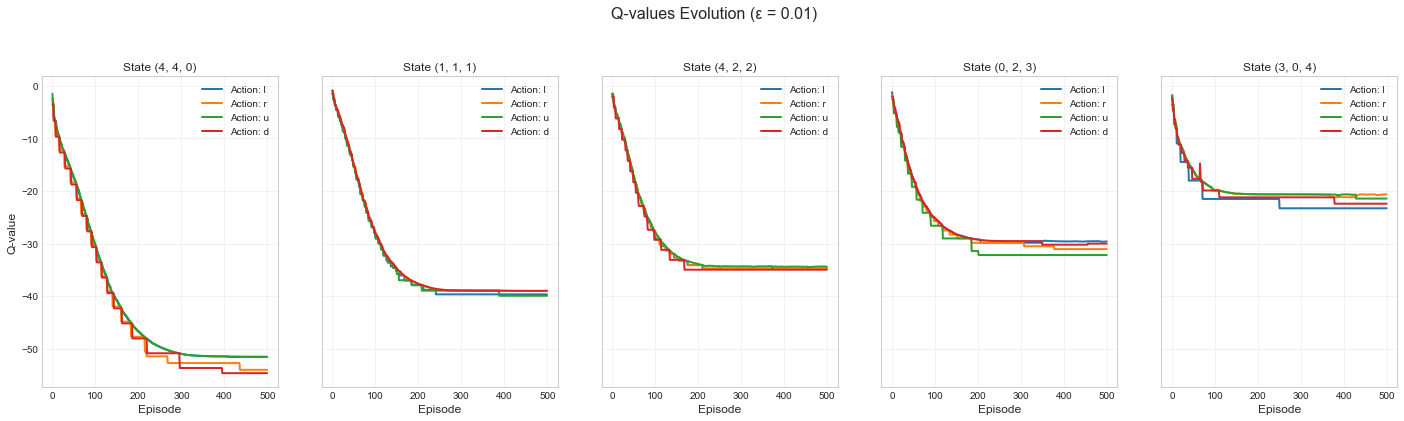

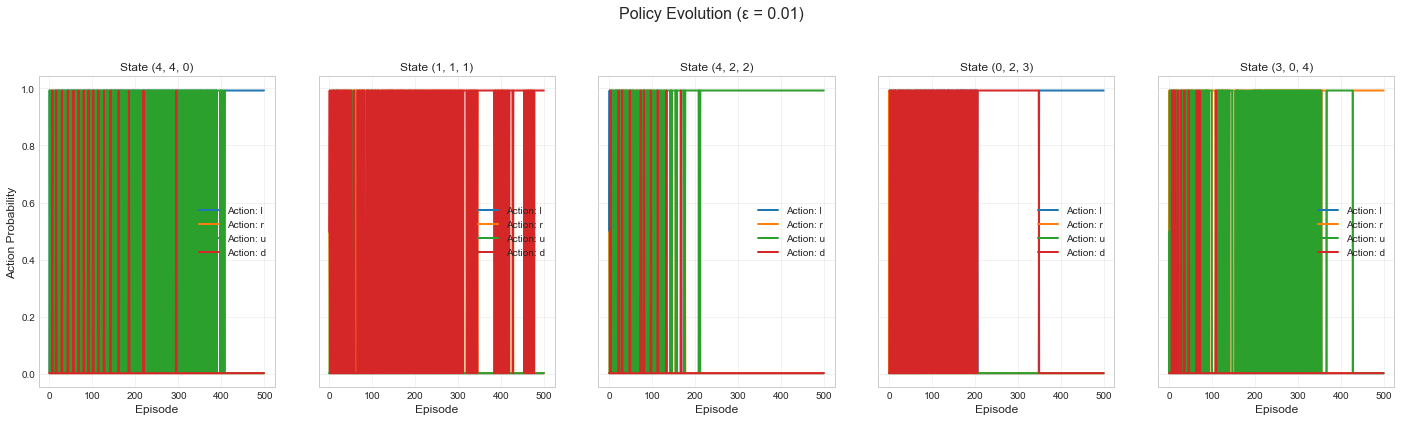

Epsilon = 0.1

Policy: {(2, 0, 2): {'l': 0.025, 'r': 0.025, 'u': 0.925, 'd': 0.025}, (4, 0, 4): {'l': 0.025, 'r': 0.025, 'u': 0.925, 'd': 0.025}, (0, 1, 0): {'l': 0.025, 'r': 0.025, 'u': 0.925, 'd': 0.025}, (4, 0, 1): {'l': 0.025, 'r': 0.925, 'u': 0.025, 'd': 0.025}, (2, 1, 3): {'l': 0.925, 'r': 0.025, 'u': 0.025, 'd': 0.025}, (0, 3, 3): {'l': 0.925, 'r': 0.025, 'u': 0.025, 'd': 0.025}, (4, 4, 4): {'l': 0.025, 'r': 0.025, 'u': 0.925, 'd': 0.025}, (3, 2, 1): {'l': 0.025, 'r': 0.025, 'u': 0.025, 'd': 0.925}, (1, 3, 3): {'l': 0.025, 'r': 0.925, 'u': 0.025, 'd': 0.025}, (1, 4, 2): {'l': 0.025, 'r': 0.025, 'u': 0.025, 'd': 0.925}, (1, 3, 0): {'l': 0.025, 'r': 0.025, 'u': 0.925, 'd': 0.025}, (3, 4, 4): {'l': 0.025, 'r': 0.025, 'u': 0.925, 'd': 0.025}, (3, 3, 2): {'l': 0.025, 'r': 0.025, 'u': 0.925, 'd': 0.025}, (0, 0, 1): {'l': 0.025, 'r': 0.925, 'u': 0.025, 'd': 0.025}, (4, 1, 2): {'l': 0.025, 'r': 0.025, 'u': 0.025, 'd': 0.925}, (1, 0, 1): {'l': 0.025, 'r': 0.025, 'u': 0.025, 'd': 0.925}, 

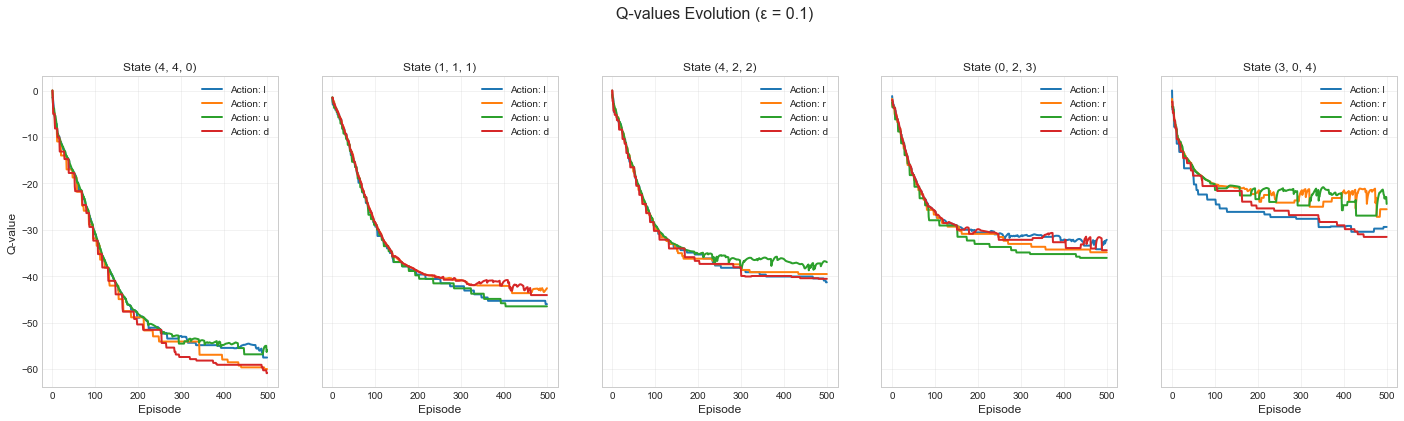

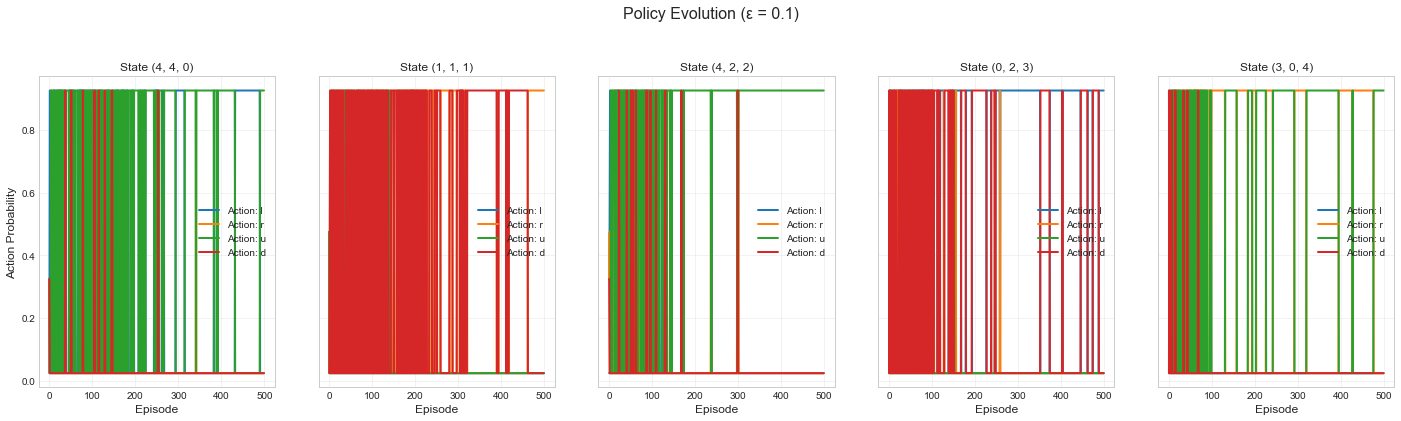

Epsilon = 0.25

Policy: {(2, 0, 2): {'l': 0.0625, 'r': 0.0625, 'u': 0.8125, 'd': 0.0625}, (4, 0, 4): {'l': 0.0625, 'r': 0.8125, 'u': 0.0625, 'd': 0.0625}, (0, 1, 0): {'l': 0.8125, 'r': 0.0625, 'u': 0.0625, 'd': 0.0625}, (4, 0, 1): {'l': 0.0625, 'r': 0.8125, 'u': 0.0625, 'd': 0.0625}, (2, 1, 3): {'l': 0.0625, 'r': 0.0625, 'u': 0.0625, 'd': 0.8125}, (0, 3, 3): {'l': 0.0625, 'r': 0.0625, 'u': 0.0625, 'd': 0.8125}, (4, 4, 4): {'l': 0.0625, 'r': 0.0625, 'u': 0.8125, 'd': 0.0625}, (3, 2, 1): {'l': 0.0625, 'r': 0.0625, 'u': 0.0625, 'd': 0.8125}, (1, 3, 3): {'l': 0.8125, 'r': 0.0625, 'u': 0.0625, 'd': 0.0625}, (1, 4, 2): {'l': 0.8125, 'r': 0.0625, 'u': 0.0625, 'd': 0.0625}, (1, 3, 0): {'l': 0.8125, 'r': 0.0625, 'u': 0.0625, 'd': 0.0625}, (3, 4, 4): {'l': 0.0625, 'r': 0.0625, 'u': 0.8125, 'd': 0.0625}, (3, 3, 2): {'l': 0.0625, 'r': 0.0625, 'u': 0.8125, 'd': 0.0625}, (0, 0, 1): {'l': 0.0625, 'r': 0.0625, 'u': 0.0625, 'd': 0.8125}, (4, 1, 2): {'l': 0.0625, 'r': 0.0625, 'u': 0.8125, 'd': 0.0625}, 

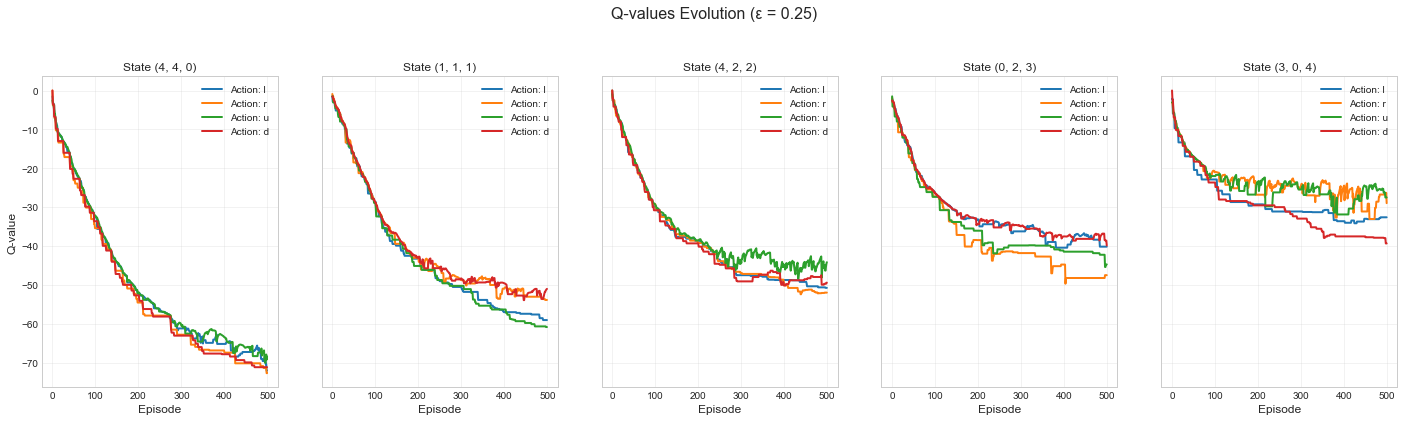

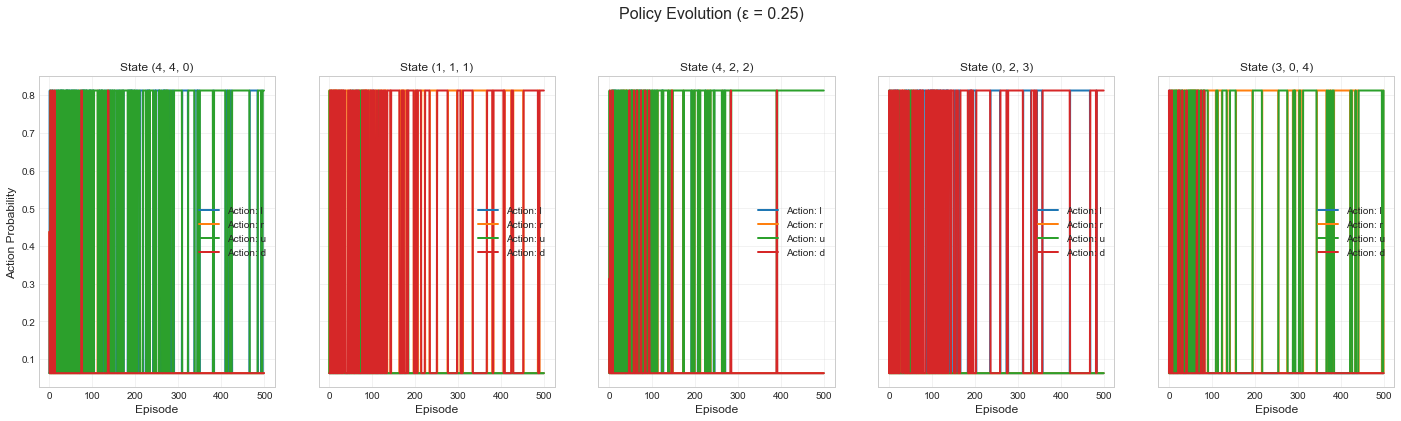

In [129]:
for epsilon in (0.01, 0.1, 0.25):
    env = Flags()
    sarsa_agent = SarsaAgent(env, epsilon=epsilon, episodes=500, max_steps=200)
    sarsa_agent.train()
    policy = sarsa_agent.get_policy()
    print(f"Epsilon = {epsilon}\n")
    print(f"Policy: {policy}\n")
    print(f"Q: {sarsa_agent.q_table}")
    path, _, _ = follow_policy_TD(env, policy)
    create_plots_TD(
        env, sarsa_agent.q_history, sarsa_agent.policy_history, sarsa_agent.epsilon
    )

    if abs(epsilon - 0.01) < 1e-4:
        policy_sarsa = policy
        q_sarsa = sarsa_agent.q_table
        path_sarsa = path

In terms of convergence of Q-values, all the plots for the three epsilon values seem to be converging. However, the variance of each plot is noticeable as the value of epsilon increases.

- Epsilon = 0.01: the Q-values are the most stable and there is minimal oscillation. This is likely due to the higher degree of greediness of the policy with this approach.
- Epsilon = 0.1: the values seem to converge but certain states demonstrate higher oscillations than when using an epsilon value of 0.01. 
- Epsilon = 0.25: the pattern of the curves for this value is similar to that of 0.1, but the flunctuations happen more often.

With this, considering the fact that all three epsilon values reach the goal state in the optimal path length (26); the best epsilon is 0.01 since it demonstrates the best convergence of the Q-values - which means that it generates the best estimate of the optimal Q function.

Please see the console outputs above for the Q function and policy obtained for each epsilon.

### 5 Comparing Algorithms [25 Marks]

In the final section of your report, you must compare the different control algorithm you implemented on the Flags domain. In particular, please comment on at least the following issues in your report:

(a) Were the Q-value functions and policies you obtained using each algorithm similar? Were they different? Comment on this using the properties of each algorithm you learned in class [6 Marks]

(b) Use the plots you created for each ε to make a detailed comparison of the performance of the algorithms implemented in 3.2, 4.1 and 4.2. Answer the following questions for each ε you tested. Which one converged the fastest on average? Which one the slowest? Which one
had lower variance and which had higher variance? Why? [6 Marks]

(c) choose one particular ε for all three algorithms and one of the importance sampling Monte Carlo control, compare their testing performances of policies learned by all the algorithm (try to visualize this comparison). [13 Marks]

**Part a)**

In [132]:
print(f"First Visit MC:")
print(f"\tState: {(4, 4, 0)}; Policy: {policy_first_visit_mc[(4, 4, 0)]}; Q: {q_first_visit_mc[((4, 4, 0), 'l')]}")
print(f"\tState: {(1, 1, 1)}; Policy: {policy_first_visit_mc[(1, 1, 1)]}; Q: {q_first_visit_mc[((1, 1, 1), 'r')]}")
print(f"\tState: {(4, 2, 2)}; Policy: {policy_first_visit_mc[(4, 2, 2)]}; Q: {q_first_visit_mc[((4, 2, 2), 'u')]}")
print(f"\tState: {(0, 2, 3)}; Policy: {policy_first_visit_mc[(0, 2, 3)]}; Q: {q_first_visit_mc[((0, 2, 3), 'd')]}")
print(f"\tState: {(3, 0, 4)}; Policy: {policy_first_visit_mc[(3, 0, 4)]}; Q: {q_first_visit_mc[((3, 0, 4), 'u')]}")
print(f"Off-Policy MC:")
print(f"\tState: {(4, 4, 0)}; Policy: {policy_off_policy_mc[(4, 4, 0)]}; Q: {q_off_policy_mc[((4, 4, 0), 'l')]}")
print(f"\tState: {(1, 1, 1)}; Policy: {policy_off_policy_mc[(1, 1, 1)]}; Q: {q_off_policy_mc[((1, 1, 1), 'l')]}")
print(f"\tState: {(4, 2, 2)}; Policy: {policy_off_policy_mc[(4, 2, 2)]}; Q: {q_off_policy_mc[((4, 2, 2), 'u')]}")
print(f"\tState: {(0, 2, 3)}; Policy: {policy_off_policy_mc[(0, 2, 3)]}; Q: {q_off_policy_mc[((0, 2, 3), 'l')]}")
print(f"\tState: {(3, 0, 4)}; Policy: {policy_off_policy_mc[(3, 0, 4)]}; Q: {q_off_policy_mc[((3, 0, 4), 'r')]}")
print(f"Q Learning:")
print(f"\tState: {(4, 4, 0)}; Policy: {policy_q_learning[(4, 4, 0)]}; Q: {q_q_learning[(4, 4, 0)]}")
print(f"\tState: {(1, 1, 1)}; Policy: {policy_q_learning[(1, 1, 1)]}; Q: {q_q_learning[(1, 1, 1)]}")
print(f"\tState: {(4, 2, 2)}; Policy: {policy_q_learning[(4, 2, 2)]}; Q: {q_q_learning[(4, 2, 2)]}")
print(f"\tState: {(0, 2, 3)}; Policy: {policy_q_learning[(0, 2, 3)]}; Q: {q_q_learning[(0, 2, 3)]}")
print(f"\tState: {(3, 0, 4)}; Policy: {policy_q_learning[(3, 0, 4)]}; Q: {q_q_learning[(3, 0, 4)]}")
print(f"SARSA:")
print(f"\tState: {(4, 4, 0)}; Policy: {policy_sarsa[(4, 4, 0)]}; Q: {q_sarsa[(4, 4, 0)]}")
print(f"\tState: {(1, 1, 1)}; Policy: {policy_sarsa[(1, 1, 1)]}; Q: {q_sarsa[(1, 1, 1)]}")
print(f"\tState: {(4, 2, 2)}; Policy: {policy_sarsa[(4, 2, 2)]}; Q: {q_sarsa[(4, 2, 2)]}")
print(f"\tState: {(0, 2, 3)}; Policy: {policy_sarsa[(0, 2, 3)]}; Q: {q_sarsa[(0, 2, 3)]}")
print(f"\tState: {(3, 0, 4)}; Policy: {policy_sarsa[(3, 0, 4)]}; Q: {q_sarsa[(3, 0, 4)]}")

First Visit MC:
	State: (4, 4, 0); Policy: [0.0625, 0.0625, 0.8125, 0.0625]; Q: -311.2311647633239
	State: (1, 1, 1); Policy: [0.0625, 0.8125, 0.0625, 0.0625]; Q: -93.81585658943243
	State: (4, 2, 2); Policy: [0.0625, 0.0625, 0.8125, 0.0625]; Q: -67.12378649226895
	State: (0, 2, 3); Policy: [0.0625, 0.0625, 0.0625, 0.8125]; Q: -52.69529050585473
	State: (3, 0, 4); Policy: [0.0625, 0.8125, 0.0625, 0.0625]; Q: -35.26094941319796
Off-Policy MC:
	State: (4, 4, 0); Policy: l; Q: 0
	State: (1, 1, 1); Policy: u; Q: -5.0
	State: (4, 2, 2); Policy: u; Q: -3.0
	State: (0, 2, 3); Policy: d; Q: -6.159999999999999
	State: (3, 0, 4); Policy: u; Q: -8.700000000000001
Q Learning:
	State: (4, 4, 0); Policy: {'l': 0.0025, 'r': 0.0025, 'u': 0.9924999999999999, 'd': 0.0025}; Q: {'l': -51.466896267778985, 'r': -53.20895294786675, 'u': -51.46686634554026, 'd': -52.79937472208036}
	State: (1, 1, 1); Policy: {'l': 0.0025, 'r': 0.0025, 'u': 0.0025, 'd': 0.9924999999999999}; Q: {'l': -39.31002491851887, 'r': -3

Please see above for the policy and Q values at 5 specific states of interest (initial state and states of the environment once a flag is captured).

1. State (4, 4, 0):

- First-visit MC: UP with 81.25% probability
- Off-policy MC: LEFT
- Q-learning: UP with 99% probability
- SARSA: LEFT with 99% probability

- All algorithms act optimally towards capturing flag 1. In terms of Q-values, first-visit MC has the lowest value, Q-learning and SARSA have very similar values (with Q-learning demonstrating a slightly higher value), and Off-policy MC shows the maximum value (0) which may not be accurate since the Q-function estimated with this algorithm is not a good estimation of the optimal Q-function (since in Part 3.3, the goal state was not being reached).

2. State (1, 1, 1)

- First-visit MC: RIGHT with 81.25% probability
- Off-policy MC: UP
- Q-learning: DOWN with 99% probability
- SARSA: DOWN with 99% probability 

- First-visit MC, Q-learning, and SARSA select optimal actions towards flag 2. However, Off-policy MC selects a suboptimal action. This is an indication that the estimated policy for the off-policy MC method is not a good estimation of the true optimal policy. This is also the reason why the goal state was not being reached. In terms of the Q-values, the pattern remains the same as before, with Q-learning and SARSA displaying similar values, and first-visit MC being the lowest.

3. State (4, 2, 2)

- First-visit MC: UP with 81.25% probability
- Off-policy MC: UP
- Q-learning: UP with 99% probability
- SARSA: UP with 99% probability 

- All algorithms act optimally to capture flag 3 from (4, 2, 2). The pattern of Q-values amongst the algorithms remain the same as before.

4. State (0, 2, 3)

- First-visit MC: DOWN with 81.25% probability
- Off-policy MC: DOWN
- Q-learning: LEFT with 99% probability
- SARSA: LEFT with 99% probability 

- All the algorithms behave optimally and are on the optimal path towards flag 4. The pattern of Q-values remain the same.

5. State (3, 0, 4)

- First-visit MC: RIGHT with 81.25% probability
- Off-policy MC: UP
- Q-learning: UP with 99% probability
- SARSA: RIGHT with 99% probability 

- All the algorithms act according to an optimal path towards the goal state. 

Overall, first-visit MC, Q-learning, and SARSA demonstrate good approximations to the optimal policy since in the 5 states analyzed, the optimal action was chosen each time. Off-policy MC selects suboptimal actions in certain states which indicates a poor estimation of the optimal policy. The poor result of the off-policy MC may be attributed to the chosen behaviour policy as sampling rewards from that policy led to poor learning of the policy and Q.

**Part b)**

Epsilon = 0.01

Based on the Q value function plots of the first-visit Monte Carlo, Q-learning, and SARSA methods; it is evident that Q-learning converges the fastest. After 300 episodes, the Q-values are very stable and have minimal oscillation. The slowest is the first-visit Monte Carlo, as Q-value convergence only seems to occur after around 1500 episodes. This is a logical result since Monte Carlo depends on sampled episodes for learning. In terms of variance, the result is the same. Q-learning has very small variance and the plot is a very smooth curve. Whereas, first-visit Monte Carlo has abrupt changes in its graph and does not look differentiable. This is likely due to Monte Carlo's nature of minimal bootstrapping and only relying on sample returns for estimating Q; which leads to high variance - especially since the samples may have high variance.


Epsilon = 0.1

For this epsilon value, the fastest convergence is still achieved by Q-learning. After around 400 epsidoes, the Q-values are quite constant and stable. As before, first-visit Monte Carlo has the slowest convergence since the values are only stabilized after around 1500 episodes. In terms of variance; first-visit Monte Carlo after 1500 episodes has very low variance as well as Q-learning after 400 episodes. The plots are very close to horizontal lines, which is an indication of low variance. In fact, SARSA demonstrates high variance with this epsilon value as the values seem to oscillate strongly even near the end of the 500 episodes. This may be the case since the policy is less greedy and more randomness is added to action selection, which may delay the convergence of SARSA.


Epsilon = 0.25

Once again, Q-learning achieves convergence with the smallest number of episodes. The Q-values seem to converge very quickly with this epsilon value as after 300 episodes, most actions for the graphed states display a horizontal line. The slowest is again first-visit Monte Carlo, but the Q-values demonstrate good convergence after 1200 episodes. From the graphs, first-visit Monte Carlo and Q-learning display the lowest variance. The Monte Carlo method shows very low variance near the end of the 2000 episodes and converges extremely well. Similarly, after 400 episodes, Q-learning achieved stability in Q-values. SARSA shows high variance as even near the end of the 500 episodes, the Q-values were oscillating significantly. The reason for this is likely due to actions (and thus subsequent states) being selected randomly at a much higher probability, and the policy is much less greedy than the other epsilon values. This introduces more randomness and likely causes the higher variance.

**Part c)**

Epsilon = 0.25

- We compared the testing performances of four polices from first-visit MC, OIS off policy MC, Q-learning, and SARSA algorithms by drawing the approximate optimal policy with output paths. 

To represent the results below, each 5x5 grid represensts the intermediate stages while it reaches the goal state. The number marked on each cell represents how many steps the agent passed through from the initial state. 

- For first-visit MC, the agent found optimal paths until it collects Flag 2 (Flag 0 -> Flag 2). But it spents 2 additional steps which lengthen the path at the stage of Flag 2 -> Flag 3. This loosen the performance of optimality.
- For OIS off-policy MC, the agent failed to find target policy from the beginning by moving left forwards. 
- For Q-Learning and SARSA, the agent found optimal path along the entire states (Flag 0 -> Flag 4). Even though they have different optimal paths, the total lengths are same.

Policy paths of first visit MC


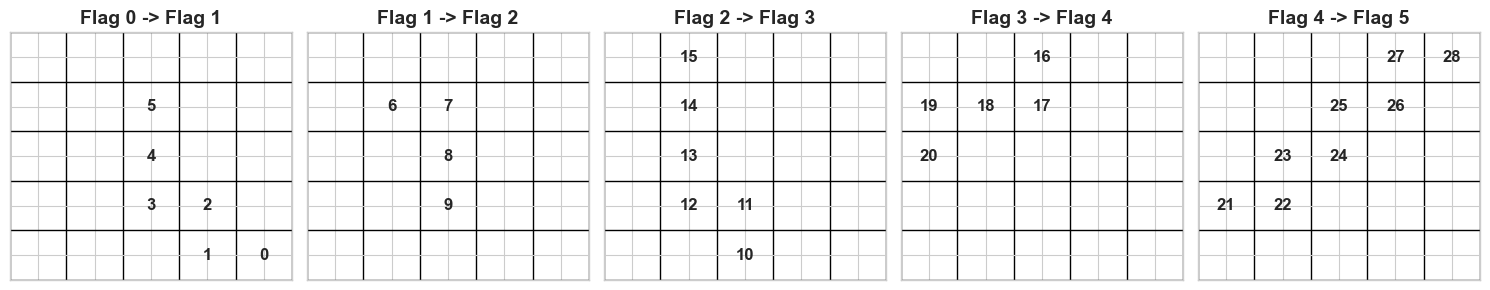

Policy paths of off policy MC


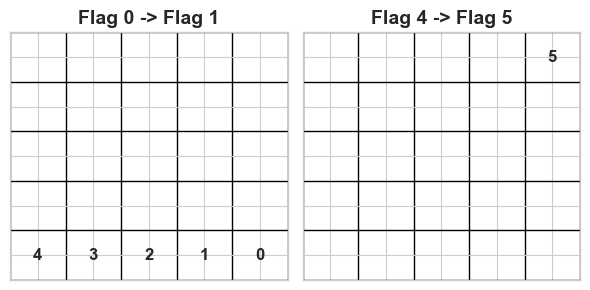

Policy paths of Q learning


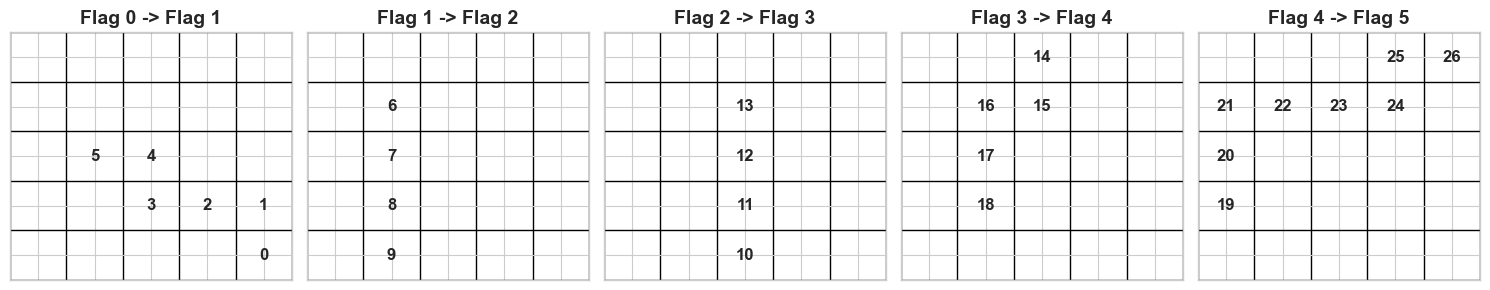

Policy paths of SARSA


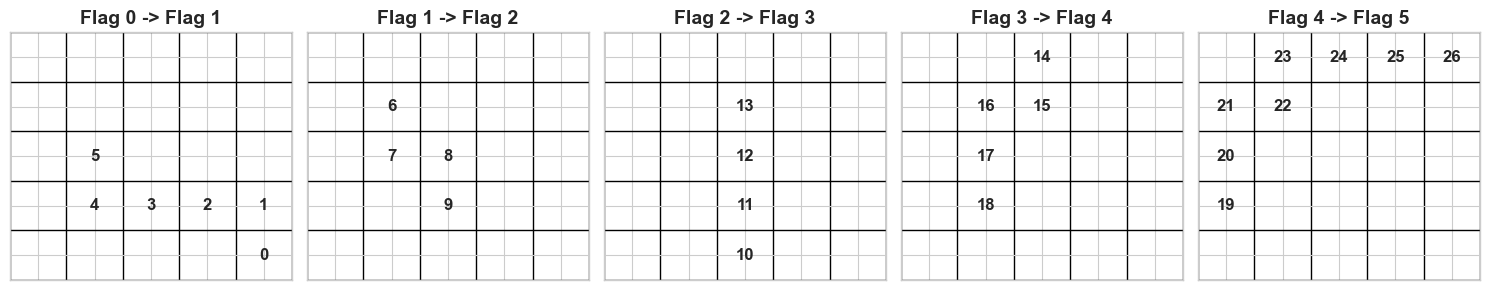

In [249]:
# Draw policy paths from each algorithm

# print(path_first_visit_mc)
# print(path_off_policy_mc)
# print(path_q_learning)
# print(path_sarsa)

import numpy as np
import matplotlib.pyplot as plt

def visualize_flagged_paths(grid_size, path):

    flagged_paths = {}
    for (x, y, flag) in path:
        if flag not in flagged_paths:
            flagged_paths[flag] = []
        flagged_paths[flag].append((x, y))

    num_flags = len(flagged_paths)  # Number of unique flags

    # Create a single figure with subplots
    fig, axes = plt.subplots(1, num_flags, figsize=(3 * num_flags, 3))

    if num_flags == 1:  
        axes = [axes]
    steps = -1
    for ax, (flag, points) in zip(axes, sorted(flagged_paths.items())):
        grid = np.full(grid_size, '', dtype='<U2')
        
        for step, (x, y) in enumerate(points, start=1):  # Start numbering from 1
            grid[y, 4-x] = str(steps + step)  # Mark steps
        steps += step
        
        ax.set_xticks(np.arange(grid_size[1] + 1) - 0.5, minor=True)
        ax.set_yticks(np.arange(grid_size[0] + 1) - 0.5, minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
        ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
        ax.set_title(f"Flag {flag} -> Flag {flag+1}", fontsize=14, fontweight='bold')

        # Add numbers to grid cells
        for y in range(grid_size[0]):
            for x in range(grid_size[1]):
                if grid[x, y]:
                    ax.text(x, y, grid[x, y], ha='center', va='center', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Policy paths of first visit MC")
visualize_flagged_paths((5, 5), path_first_visit_mc)
print("Policy paths of off policy MC")
visualize_flagged_paths((5, 5), path_off_policy_mc)
print("Policy paths of Q learning")
visualize_flagged_paths((5, 5), path_q_learning)
print("Policy paths of SARSA")
visualize_flagged_paths((5, 5), path_sarsa)